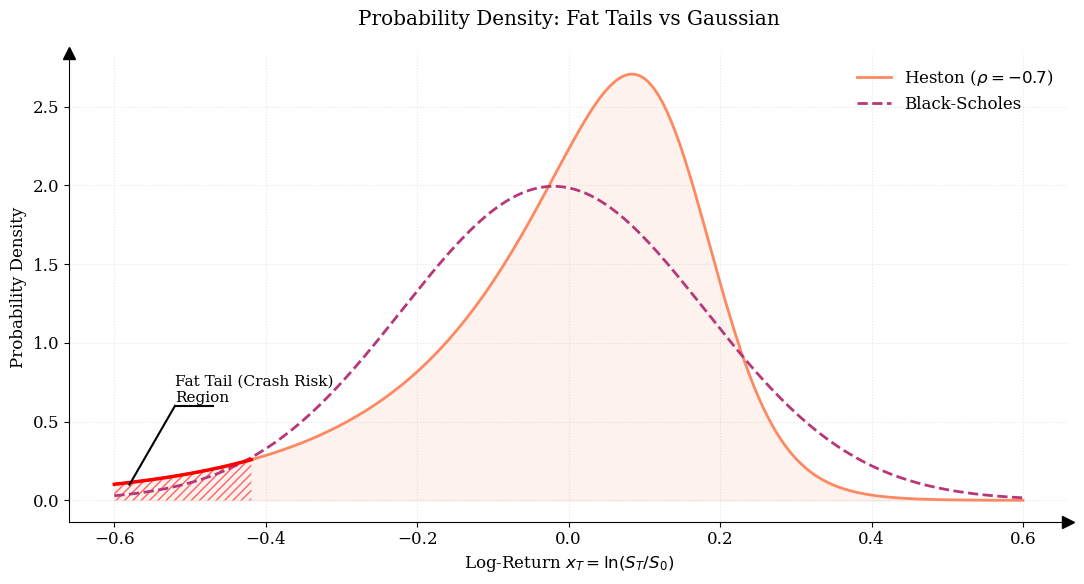

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm

# --- STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif", "font.size": 12, "axes.grid": True, 
    "grid.alpha": 0.3, "grid.linestyle": ":", "axes.spines.top": False, "axes.spines.right": False
})
cmap = plt.get_cmap('magma')
C_BASE = cmap(0.5)   # Purple (BS)
C_HIGH = cmap(0.75)  # Orange (Heston)
C_TEXT = "black"

# --- CALCULATIONS ---
T = 1.0; r = 0.0; kappa = 2.0; theta = 0.04; xi = 0.5; rho = -0.7; v0 = 0.04

def heston_char_func(u):
    d = np.sqrt((1j * rho * xi * u - kappa)**2 + xi**2 * (1j * u + u**2))
    g = (kappa - 1j * rho * xi * u - d) / (kappa - 1j * rho * xi * u + d)
    C = (kappa * theta / xi**2) * ((kappa - 1j * rho * xi * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
    D = ((kappa - 1j * rho * xi * u - d) / xi**2) * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))
    return np.exp(C + D * v0)

def get_density(x_val):
    integrand = lambda u: np.real(np.exp(-1j * u * x_val) * heston_char_func(u))
    # Using larger limit for better tail precision
    return quad(integrand, 0, 200, limit=500)[0] / np.pi 

x_grid = np.linspace(-0.6, 0.6, 200) # More points for smoother tail fill
dens_heston = np.array([get_density(x) for x in x_grid])
sigma_bs = np.sqrt(theta)
dens_bs = norm.pdf(x_grid, loc=-0.5*sigma_bs**2*T, scale=sigma_bs*np.sqrt(T))

# --- FAT TAIL ZONE DEFINITION ---
# We define the tail as the area where x < -0.25 (arbitrary, for visual example)
tail_threshold = -0.415
mask_tail = x_grid < tail_threshold
x_tail = x_grid[mask_tail]
y_tail = dens_heston[mask_tail]

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(11, 6))

# 1. Main curves
ax.plot(x_grid, dens_heston, color=C_HIGH, linewidth=2, label=r'Heston ($\rho=-0.7$)')
ax.fill_between(x_grid, dens_heston, color=C_HIGH, alpha=0.1) # Global light orange fill
ax.plot(x_grid, dens_bs, color=C_BASE, linestyle='--', linewidth=2, label='Black-Scholes')

# 2. Highlighting the Fat Tail (Red + Hatching)
# Red boundary on the curve
ax.plot(x_tail, y_tail, color='red', linewidth=2.5) 
# Red hatched fill (diagonal grid)
# hatch='////' gives fine and close diagonal lines
ax.fill_between(x_tail, y_tail, 0, 
                facecolor="none", # Transparent background
                edgecolor="red",  # Line color
                hatch='////',     # Hatch pattern
                linewidth=0,      # No border around the fill area
                alpha=0.6)

# Axes & Arrows formatting
ax.spines['left'].set_color(C_TEXT); ax.spines['bottom'].set_color(C_TEXT)
ax.tick_params(colors=C_TEXT)
ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)
ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)

# Labels
ax.set_title(r"Probability Density: Fat Tails vs Gaussian", color=C_TEXT, pad=20)
ax.set_xlabel(r"Log-Return $x_T = \ln(S_T/S_0)$", color=C_TEXT)
ax.set_ylabel("Probability Density", color=C_TEXT)

# --- BROKEN LINE ANNOTATION ---
target_x, target_y = -0.58, 0.10 # Pointing towards the hatched area
text_x, text_y = -0.52, 0.6
elbow_x = -0.52

ax.text(text_x, text_y+0.1, 'Fat Tail (Crash Risk)\nRegion', 
        color=C_TEXT, va='center', ha='left', fontsize=11)

ax.plot([text_x+0.05, elbow_x], [text_y, text_y], color=C_TEXT, lw=1.5)
ax.plot([elbow_x, target_x], [text_y, target_y], color=C_TEXT, lw=1.5)

ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

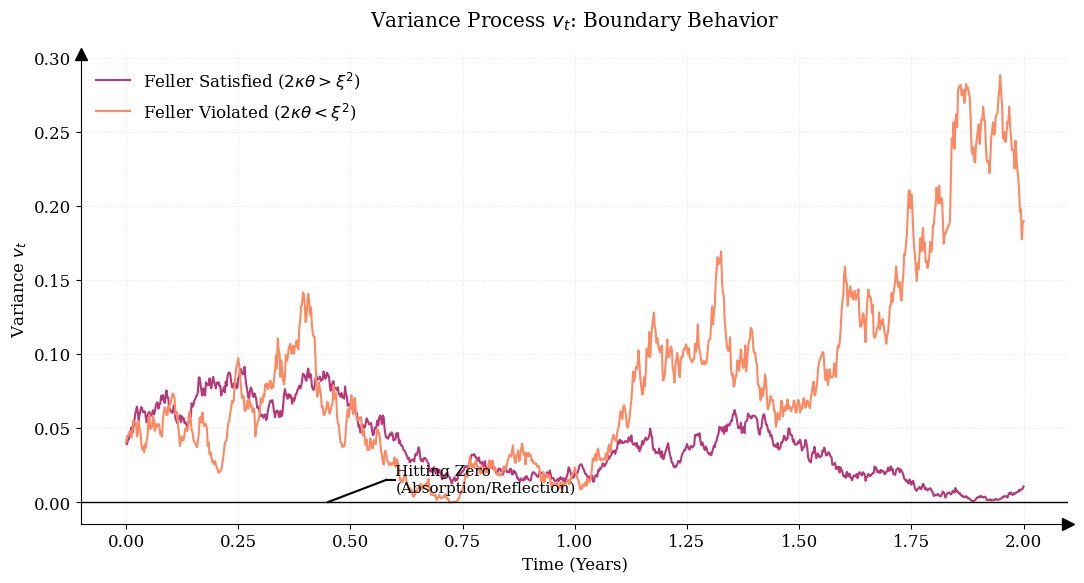

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

# --- STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif", "font.size": 12, "axes.grid": True, 
    "grid.alpha": 0.3, "grid.linestyle": ":", "axes.spines.top": False, "axes.spines.right": False
})
cmap = plt.get_cmap('magma')
C_BASE = cmap(0.5)   # Purple
C_HIGH = cmap(0.75)  # Orange
C_TEXT = "black"

# --- CALCULATIONS ---
T = 2.0; N = 1000; dt = T/N; t = np.linspace(0, T, N+1)
#np.random.seed(42)

def simulate_cir(kappa, theta, xi, v0):
    v = np.zeros(N+1); v[0] = v0
    dW = np.random.normal(0, np.sqrt(dt), N)
    for i in range(N):
        v_curr = max(v[i], 0)
        v[i+1] = v[i] + kappa * (theta - v_curr) * dt + xi * np.sqrt(v_curr) * dW[i]
    return v

v_safe = simulate_cir(2.0, 0.04, 0.3, 0.04)
v_danger = simulate_cir(1.0, 0.02, 0.5, 0.04)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(11, 6))

# Curves
ax.plot(t, v_safe, color=C_BASE, linewidth=1.5, label=r'Feller Satisfied ($2\kappa\theta > \xi^2$)')
ax.plot(t, v_danger, color=C_HIGH, linewidth=1.5, label=r'Feller Violated ($2\kappa\theta < \xi^2$)')
ax.axhline(0, color=C_TEXT, linewidth=1)

# Axes & Arrows formatting
ax.spines['left'].set_color(C_TEXT); ax.spines['bottom'].set_color(C_TEXT)
ax.tick_params(colors=C_TEXT)
ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)
ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)

# Labels
ax.set_title(r"Variance Process $v_t$: Boundary Behavior", color=C_TEXT, pad=20)
ax.set_xlabel("Time (Years)", color=C_TEXT)
ax.set_ylabel(r"Variance $v_t$", color=C_TEXT)

# --- BROKEN LINE ANNOTATION (DRAWING STYLE) ---
# Coordinates of the target point (where the curve touches 0)
target_x, target_y = 0.45, 0.0
# Coordinates of the text (further away)
text_x, text_y = 0.6, 0.015

# Text
ax.text(text_x, text_y, 'Hitting Zero\n(Absorption/Reflection)', 
        ha='left', va='center', color=C_TEXT, fontsize=11)

# Custom broken line
# We define an intermediate "elbow" point to create the angle
elbow_x = text_x - 0.02 # Slightly to the left of the text
elbow_y = text_y        # Same height as the text

# We plot the two segments
# 1. Horizontal segment (from text to elbow)
ax.plot([text_x, elbow_x], [text_y, elbow_y], color='black', lw=1.5)
# 2. Oblique segment (from elbow to target point)
ax.plot([elbow_x, target_x], [elbow_y, target_y], color='black', lw=1.5)

# Legend
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

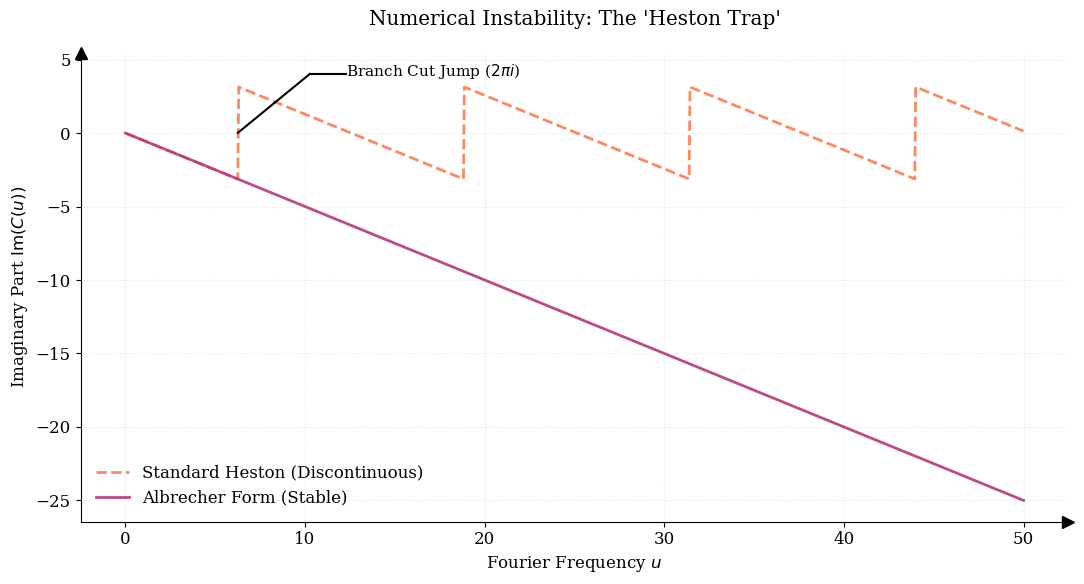

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif", "font.size": 12, "axes.grid": True, 
    "grid.alpha": 0.3, "grid.linestyle": ":", "axes.spines.top": False, "axes.spines.right": False
})
cmap = plt.get_cmap('magma')
C_BASE = cmap(0.5)   # Light Purple (0.5)
C_HIGH = cmap(0.75)  # Orange
C_TEXT = "black"

# --- CALCULATIONS ---
u = np.linspace(0, 50, 1000)
true_phase = -0.5 * u 
unstable_imag = (true_phase + np.pi) % (2 * np.pi) - np.pi

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(11, 6))

# Curves with linewidth = 1.5
ax.plot(u, unstable_imag, color=C_HIGH, linestyle='--', linewidth=2, label='Standard Heston (Discontinuous)')
ax.plot(u, true_phase, color=C_BASE, linewidth=2, alpha=0.9, label='Albrecher Form (Stable)')

# Axes & Arrows formatting
ax.spines['left'].set_color(C_TEXT); ax.spines['bottom'].set_color(C_TEXT)
ax.tick_params(colors=C_TEXT)
ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)
ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)

# Labels
ax.set_title(r"Numerical Instability: The 'Heston Trap'", color=C_TEXT, pad=20)
ax.set_xlabel(r"Fourier Frequency $u$", color=C_TEXT)
ax.set_ylabel(r"Imaginary Part $\text{Im}(C(u))$", color=C_TEXT)

# --- BROKEN LINE ANNOTATION ---
# Identify the jump
jump_idx = np.where(np.abs(np.diff(unstable_imag)) > 3)[0][0]
x_jump = u[jump_idx]
y_jump_mid = unstable_imag[jump_idx] + np.pi # Middle of the jump

# Text and line position
text_x = x_jump + 6
text_y = y_jump_mid + 4
elbow_x = text_x - 2  # Breaking point of the line

# Text
ax.text(text_x, text_y+0.2, r'Branch Cut Jump ($2\pi i$)', 
        ha='left', va='center', color=C_TEXT, fontsize=11)

# Plotting the broken line (2 segments)
# 1. Horizontal (from text to elbow)
ax.plot([text_x, elbow_x], [text_y, text_y], color=C_TEXT, lw=1.5)
# 2. Oblique (from elbow to jump)
ax.plot([elbow_x, x_jump], [text_y, y_jump_mid], color=C_TEXT, lw=1.5)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

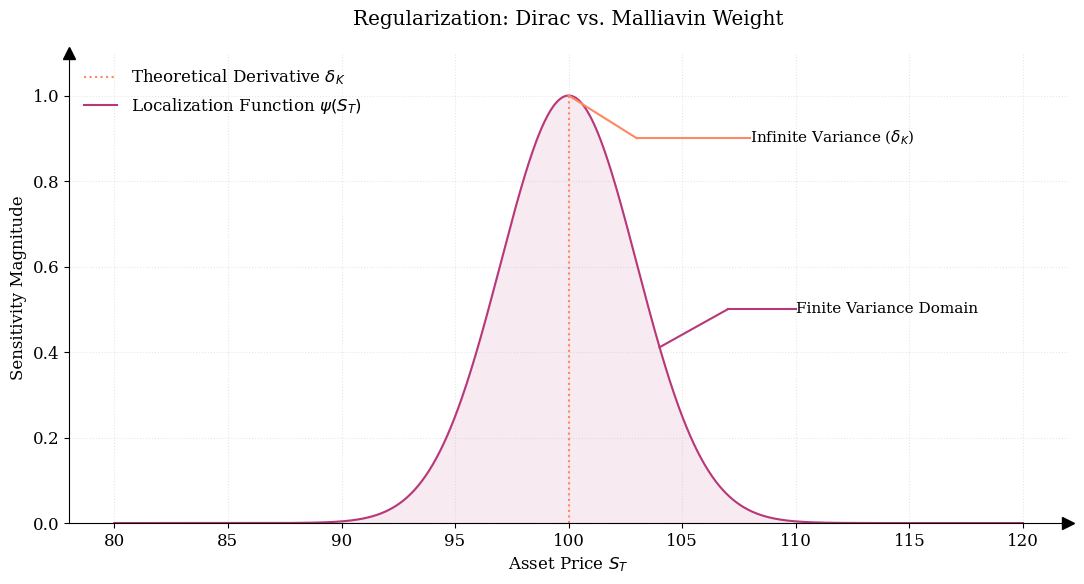

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif", "font.size": 12, "axes.grid": True, 
    "grid.alpha": 0.3, "grid.linestyle": ":", "axes.spines.top": False, "axes.spines.right": False
})
cmap = plt.get_cmap('magma')
C_BASE = cmap(0.5)   # Light Purple (0.5)
C_HIGH = cmap(0.75)  # Orange
C_TEXT = "black"

# --- CALCULATIONS ---
S = np.linspace(80, 120, 1000)
K = 100
epsilon = 3.0
dirac_x = [K, K]; dirac_y = [0, 1.0]
psi = np.exp(-0.5 * ((S - K)/epsilon)**2)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(11, 6))

# Curves (linewidth=1.5 as requested)
ax.plot(dirac_x, dirac_y, color=C_HIGH, linestyle=':', linewidth=1.5, label=r'Theoretical Derivative $\delta_K$')
ax.plot(S, psi, color=C_BASE, linewidth=1.5, label=r'Localization Function $\psi(S_T)$')
ax.fill_between(S, psi, color=C_BASE, alpha=0.1)

# Axes & Arrows formatting
ax.spines['left'].set_color(C_TEXT); ax.spines['bottom'].set_color(C_TEXT)
ax.tick_params(colors=C_TEXT)
ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)
ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)

# Labels
ax.set_title(r"Regularization: Dirac vs. Malliavin Weight", color=C_TEXT, pad=20)
ax.set_xlabel(r"Asset Price $S_T$", color=C_TEXT)
ax.set_ylabel("Sensitivity Magnitude", color=C_TEXT)
ax.set_ylim(0, 1.1)

# --- ANNOTATION 1: DIRAC (ORANGE BROKEN LINE) ---
# Target: Top of the Dirac (100, 1.0)
target_x1, target_y1 = 100, 1.0
text_x1, text_y1 = 108, 0.90  # Text shifted to the right and slightly lower
elbow_x1 = 103                # Breaking point

# Text
ax.text(text_x1, text_y1, r'Infinite Variance ($\delta_K$)', 
        color=C_TEXT, va='center', ha='left', fontsize=11)
# Lines
ax.plot([text_x1, elbow_x1], [text_y1, text_y1], color=C_HIGH, lw=1.5) # Horizontal
ax.plot([elbow_x1, target_x1], [text_y1, target_y1], color=C_HIGH, lw=1.5) # Oblique towards the peak

# --- ANNOTATION 2: LOCALIZATION (PURPLE BROKEN LINE) ---
# Target: Point on the psi curve (around S=104)
# psi(104) approx exp(-0.5 * (4/3)^2) ~ 0.41
target_x2 = 104
target_y2 = np.exp(-0.5 * ((104 - K)/epsilon)**2)
text_x2, text_y2 = 110, 0.50 # Text to the right and higher
elbow_x2 = 107               # Breaking point

# Text
ax.text(text_x2, text_y2, 'Finite Variance Domain', 
        color=C_TEXT, va='center', ha='left', fontsize=11)
# Lines
ax.plot([text_x2, elbow_x2], [text_y2, text_y2], color=C_BASE, lw=1.5) # Horizontal
ax.plot([elbow_x2, target_x2], [text_y2, target_y2], color=C_BASE, lw=1.5) # Oblique towards the curve

ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

# Partie III

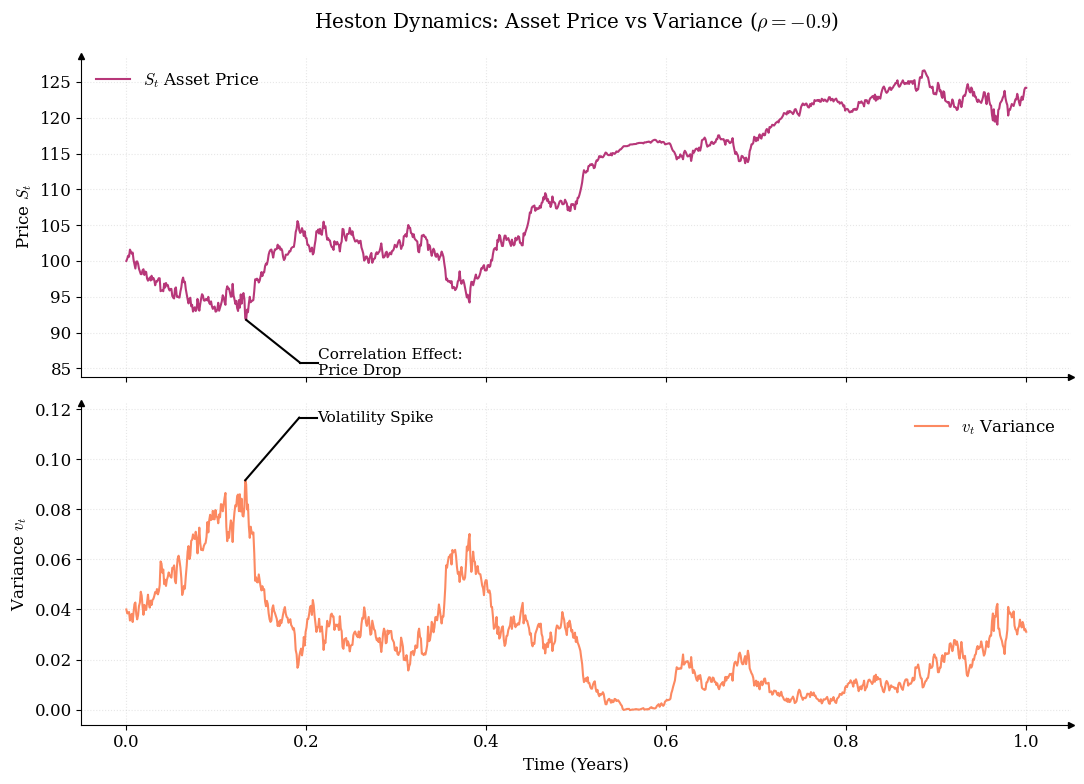

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOGIC & CALCULATIONS (UNCHANGED)
# ==========================================

# --- Base Heston Parameters ---
S0 = 100
T = 1.0
r = 0.05
kappa = 2.0
theta = 0.04
v0 = 0.04
xi = 0.5
rho = -0.7
dt = 0.001
N = int(T / dt)
time_grid = np.linspace(0, T, N)

def simulate_heston(rho, kappa, theta, xi, v0, n_paths=1):
    S = np.zeros((n_paths, N))
    v = np.zeros((n_paths, N))
    S[:, 0] = S0
    v[:, 0] = v0
    
    for t in range(1, N):
        Z1 = np.random.normal(size=n_paths)
        Z2 = np.random.normal(size=n_paths)
        W_S = Z1
        W_v = rho * Z1 + np.sqrt(1 - rho**2) * Z2
        
        v_prev = np.maximum(v[:, t-1], 0)
        dv = kappa * (theta - v_prev) * dt + xi * np.sqrt(v_prev) * np.sqrt(dt) * W_v
        v[:, t] = v[:, t-1] + dv
        
        dS = r * S[:, t-1] * dt + np.sqrt(v_prev) * S[:, t-1] * np.sqrt(dt) * W_S
        S[:, t] = S[:, t-1] + dS
    return S, v

np.random.seed(42)
S_path, v_path = simulate_heston(rho=-0.9, kappa=2.0, theta=0.04, xi=0.5, v0=0.04, n_paths=1)

# ==========================================
# 2. FINAL AESTHETICS
# ==========================================

# --- Global Style ---
plt.rcParams.update({
    "font.family": "serif", 
    "font.size": 12, 
    "axes.grid": True, 
    "grid.alpha": 0.3, 
    "grid.linestyle": ":", 
    "axes.spines.top": False, 
    "axes.spines.right": False,
    "mathtext.fontset": "cm" 
})

cmap = plt.get_cmap('magma')
C_BASE = cmap(0.5)
C_HIGH = cmap(0.75)
C_TEXT = "black"

# --- PLOT SIZE (FIGSIZE) ---
# Modify here to change size: (Width, Height)
FIGURE_SIZE = (11, 8) 

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=FIGURE_SIZE)

# ==========================================
# PLOT 1: PRICE (S_t)
# ==========================================
ax1.plot(time_grid, S_path[0], color=C_BASE, linewidth=1.5, label=r'$S_t$ Asset Price')
ax1.set_ylabel(r"Price $S_t$", color=C_TEXT)
ax1.set_title(r"Heston Dynamics: Asset Price vs Variance ($\rho = -0.9$)", color=C_TEXT, pad=20)

# CLOSE-UP Annotation
idx_min = np.argmin(S_path[0])
target_x1, target_y1 = time_grid[idx_min], S_path[0][idx_min]

# Reduced offsets to bring text closer
text_x1, text_y1 = target_x1 + 0.08, target_y1 - 6 

ax1.text(text_x1, text_y1, 'Correlation Effect:\nPrice Drop', ha='left', va='center', color=C_TEXT, fontsize=11)
elbow_x1 = text_x1 - 0.02
elbow_y1 = text_y1
ax1.plot([text_x1, elbow_x1], [text_y1, elbow_y1], color='black', lw=1.5)
ax1.plot([elbow_x1, target_x1], [elbow_y1, target_y1], color='black', lw=1.5)

# ==========================================
# PLOT 2: VARIANCE (v_t)
# ==========================================
ax2.plot(time_grid, v_path[0], color=C_HIGH, linewidth=1.5, label=r'$v_t$ Variance')
ax2.set_ylabel(r"Variance $v_t$", color=C_TEXT)
ax2.set_xlabel("Time (Years)", color=C_TEXT)

# CLOSE-UP Annotation
idx_max = np.argmax(v_path[0])
target_x2, target_y2 = time_grid[idx_max], v_path[0][idx_max]

# Reduced offsets here as well
text_x2, text_y2 = target_x2 + 0.08, target_y2 + 0.025 

ax2.text(text_x2, text_y2, 'Volatility Spike', ha='left', va='center', color=C_TEXT, fontsize=11)
elbow_x2 = text_x2 - 0.02
elbow_y2 = text_y2
ax2.plot([text_x2, elbow_x2], [text_y2, elbow_y2], color='black', lw=1.5)
ax2.plot([elbow_x2, target_x2], [elbow_y2, target_y2], color='black', lw=1.5)

# ==========================================
# FORMATTING
# ==========================================
for i, ax in enumerate([ax1, ax2]):
    loc_pos = 'upper left' if i == 0 else 'upper right'
    ax.legend(frameon=False, loc=loc_pos)
    
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)
    ax.tick_params(colors=C_TEXT)
    
    # Small arrows
    ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=4)
    ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=4)

plt.tight_layout()
plt.show()

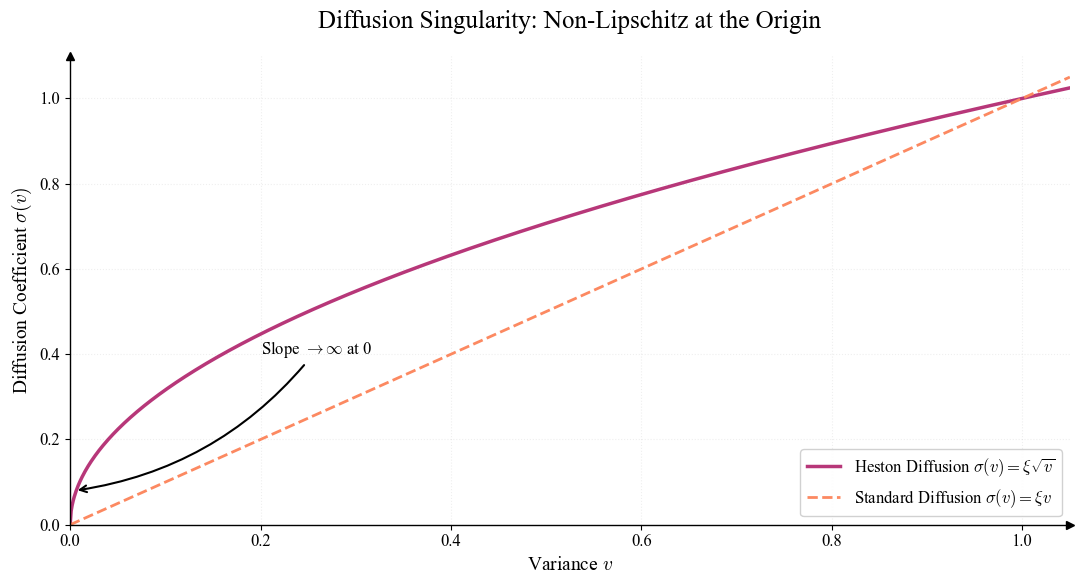

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Color Definition (Magma Palette) ---
cmap = plt.get_cmap('magma')
C_BASE = cmap(0.5)   # Purple/Red tint (For Heston)
C_HIGH = cmap(0.75)  # Orange/Gold tint (For Standard)
C_TEXT = "black"     # Text and axes

# Figure Configuration
fig, ax = plt.subplots(figsize=(11, 6))
# Global text color update for consistency
plt.rcParams.update({
    'font.size': 12,
    'text.color': C_TEXT,
    'axes.labelcolor': C_TEXT,
    'xtick.color': C_TEXT,
    'ytick.color': C_TEXT
})

# Data
x = np.linspace(0, 1.05, 1000)
y_heston = np.sqrt(x)
y_lipschitz = x

# --- 2. Plotting with new colors ---
# Heston in C_BASE (Magma 0.5)
ax.plot(x, y_heston, label=r'Heston Diffusion $\sigma(v) = \xi \sqrt{v}$', 
        color=C_BASE, linewidth=2.5)

# Standard in C_HIGH (Magma 0.75)
ax.plot(x, y_lipschitz, label=r'Standard Diffusion $\sigma(v) = \xi v$', 
        color=C_HIGH, linestyle='--', linewidth=2)

# --- 3. Arrowed Axes (Academic Style) ---
# Hide unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Center axes at origin
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_color(C_TEXT)
ax.spines['bottom'].set_color(C_TEXT)

# Add arrowheads (Triangles)
ax.plot(1, 0, ">", color=C_TEXT, transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^", color=C_TEXT, transform=ax.get_xaxis_transform(), clip_on=False)

# --- 4. Singularity Annotation ---
# Translation: "Pente -> infini en 0" becomes "Slope -> infinity at 0"
ax.annotate(r"Slope $\to \infty$ at 0",
            xy=(0.005, 0.08), xycoords='data', # Points to origin
            xytext=(0.20, 0.4), textcoords='data',
            arrowprops=dict(arrowstyle="->", 
                            connectionstyle="arc3,rad=-0.2", 
                            color=C_TEXT, lw=1.5),
            fontsize=12, color=C_TEXT)

# Titles and Labels (Translated)
ax.set_title(r"Diffusion Singularity: Non-Lipschitz at the Origin", fontsize=18, pad=20, color=C_TEXT)
ax.set_xlabel(r"Variance $v$", fontsize=14, color=C_TEXT)
ax.set_ylabel(r"Diffusion Coefficient $\sigma(v)$", fontsize=14, color=C_TEXT)

# Limits and Grid
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.2, linestyle=':') # Discrete grid
ax.legend(loc='lower right', framealpha=0.9, labelcolor=C_TEXT)

plt.tight_layout()
plt.show()


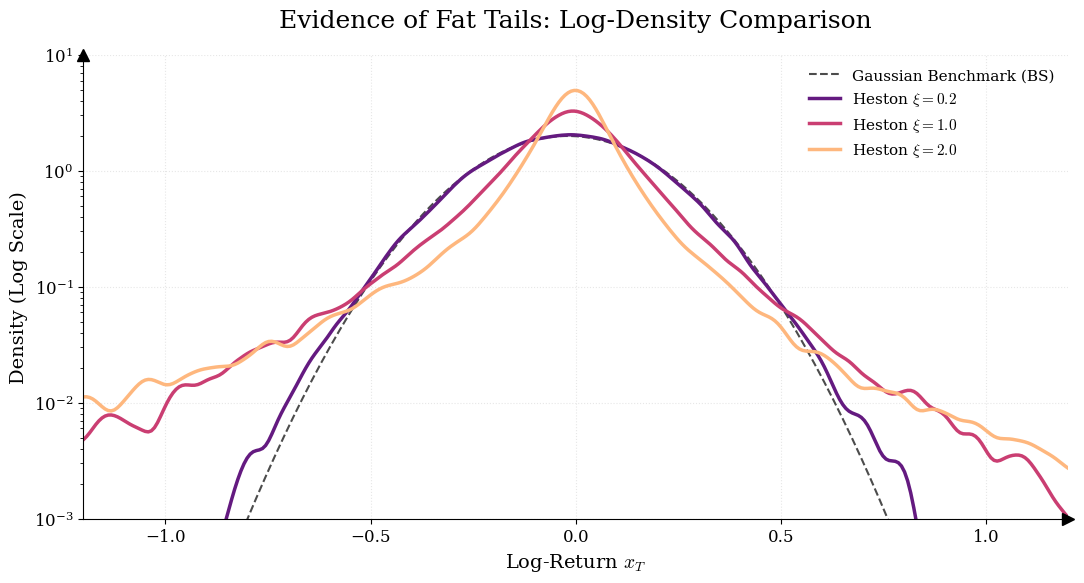

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# --- 1. STYLE CONFIGURATION (Exactly as before) ---
plt.rcParams.update({
    "font.family": "serif", 
    "font.size": 12, 
    "axes.grid": True, 
    "grid.alpha": 0.3, 
    "grid.linestyle": ":", 
    "axes.spines.top": False, 
    "axes.spines.right": False
})

# Colors
cmap = plt.get_cmap('magma')
C_TEXT = "black"

# --- 2. HESTON SIMULATION (Identical) ---
S0, T, r, theta, v0 = 100, 1.0, 0.0, 0.04, 0.04
dt = 0.002
N_steps = int(T / dt)
n_sims = 50000 

def get_log_returns(xi):
    vt = np.full(n_sims, v0)
    St = np.full(n_sims, S0)
    
    for _ in range(N_steps):
        Z1 = np.random.normal(0, 1, n_sims)
        Z2 = np.random.normal(0, 1, n_sims)
        
        vt_plus = np.maximum(vt, 0)
        dvt = 2.0 * (theta - vt_plus) * dt + xi * np.sqrt(vt_plus * dt) * Z2
        vt = vt + dvt
        
        dSt = np.sqrt(vt_plus * dt) * St * Z1 
        St = St + dSt
        
    return np.log(St / S0)

# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(11, 6))

# Widening the window slightly to observe far tails
xs = np.linspace(-1.5, 1.5, 400)

# A. Gaussian Reference (Black-Scholes)
sigma_bs = np.sqrt(theta)
pdf_bs = norm.pdf(xs, -0.5*theta*T, sigma_bs*np.sqrt(T))
ax.plot(xs, pdf_bs, color=C_TEXT, linestyle='--', linewidth=1.5, 
        label='Gaussian Benchmark (BS)', alpha=0.7)

# B. Heston Curves
xis = [0.2, 1.0, 2.0]
colors = [cmap(0.3), cmap(0.55), cmap(0.85)]

for xi, col in zip(xis, colors):
    log_rets = get_log_returns(xi)
    kde = gaussian_kde(log_rets)
    ax.plot(xs, kde(xs), color=col, linewidth=2.5, 
            label=rf'Heston $\xi={xi}$')

# --- LOG SCALE MODIFICATION ---
ax.set_yscale('log')      # Switch to log scale
ax.set_ylim(1e-3, 10)     # Adapted Y limits (no 0 in log!)
ax.set_xlim(-1.2, 1.2)    # Widened X limits

# --- 4. ARROWED AXES & STYLE ---
ax.spines['left'].set_color(C_TEXT)
ax.spines['bottom'].set_color(C_TEXT)
ax.tick_params(colors=C_TEXT)

ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)
ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)

ax.set_title(r"Evidence of Fat Tails: Log-Density Comparison", color=C_TEXT, pad=20, fontsize=18)
ax.set_xlabel(r"Log-Return $x_T$", color=C_TEXT, fontsize=14)
ax.set_ylabel("Density (Log Scale)", color=C_TEXT, fontsize=14)

# Legend
ax.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

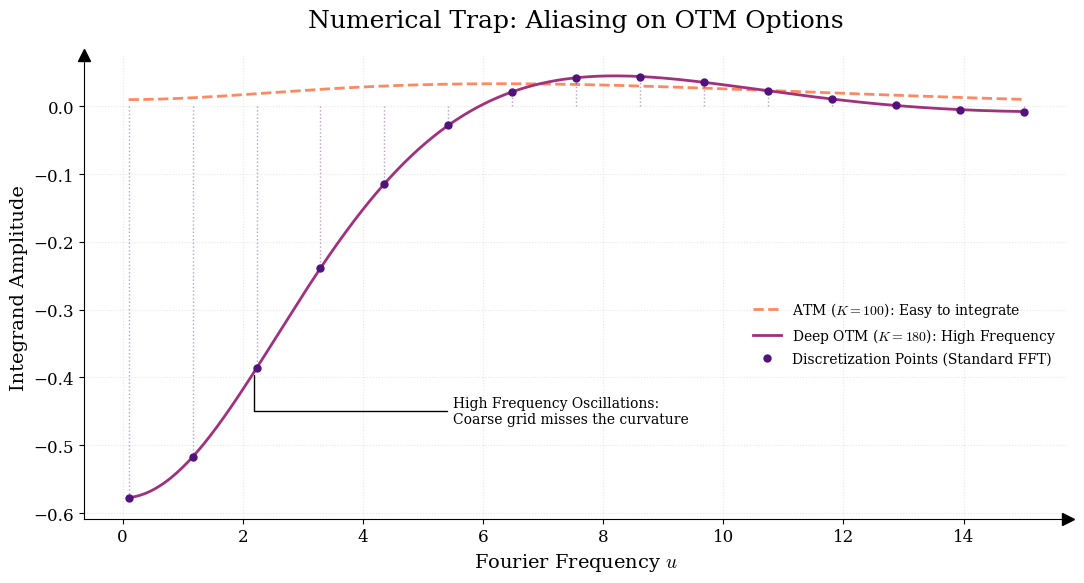

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif", 
    "font.size": 12, 
    "axes.grid": True, 
    "grid.alpha": 0.3, 
    "grid.linestyle": ":", 
    "axes.spines.top": False, 
    "axes.spines.right": False
})

# Color Palette
cmap = plt.get_cmap('magma')
C_TEXT = "black"

# --- 2. MATHEMATICAL LOGIC ---
# Heston Parameters
S0, r, v0, kappa, theta, xi, rho, T = 100.0, 0.03, 0.04, 2.0, 0.04, 0.5, -0.7, 1.0

# Heston Characteristic Function
def heston_char_func(u):
    i = 1j
    d = np.sqrt((rho * xi * u * i - kappa)**2 + xi**2 * (u * i + u**2))
    g = (kappa - rho * xi * u * i - d) / (kappa - rho * xi * u * i + d)
    D = ((kappa - rho * xi * u * i - d) / xi**2) * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))
    C = (r * u * i * T) + (kappa * theta / xi**2) * ((kappa - rho * xi * u * i - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
    return np.exp(C + D * v0 + i * u * np.log(S0))

# Integrand
def integrand(u, K):
    k = np.log(K)
    return np.real(np.exp(-1j * u * k) * heston_char_func(u) / (1j * u))

# Data
u_fine = np.linspace(0.1, 15, 500)
y_atm = integrand(u_fine, 100)
y_otm = integrand(u_fine, 180)

# Aliasing Points (Coarse Discretization)
u_coarse = np.linspace(0.1, 15, 15) 
y_coarse = integrand(u_coarse, 180)

# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(11, 6))

# A. ATM Curve (Yellow/Orange dashed)
ax.plot(u_fine, y_atm, color=cmap(0.75), linestyle='--', linewidth=2.0,
        label='ATM ($K=100$): Easy to integrate')

# B. OTM Curve (Dark/Magma color)
ax.plot(u_fine, y_otm, color=cmap(0.45), linewidth=2.0,
        label='Deep OTM ($K=180$): High Frequency')

# C. Aliasing Points
aliasing_color = cmap(0.25) 
ax.plot(u_coarse, y_coarse, 'o', color=aliasing_color, markersize=5, 
        label='Discretization Points (Standard FFT)')
ax.vlines(u_coarse, 0, y_coarse, colors=aliasing_color, linestyles='dotted', alpha=0.4, linewidth=1.0)

# --- 4. ARROWED AXES & AESTHETICS ---
ax.spines['left'].set_color(C_TEXT)
ax.spines['bottom'].set_color(C_TEXT)
ax.tick_params(colors=C_TEXT)

ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)
ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes, clip_on=False, markersize=8)

# Titles in English
ax.set_title(r"Numerical Trap: Aliasing on OTM Options", color=C_TEXT, pad=20, fontsize=18)
ax.set_xlabel(r"Fourier Frequency $u$", color=C_TEXT, fontsize=14)
ax.set_ylabel(r"Integrand Amplitude", color=C_TEXT, fontsize=14)

# Legend
ax.legend(frameon=False, loc='center right', bbox_to_anchor=(1, 0.4), fontsize=10)

# --- FIXED ANNOTATION ---
# Targeting a precise point on the curve (around u=2.2)
target_idx = 70 # Corresponds to u approximately 2.2
target_x = u_fine[target_idx]
target_y = y_otm[target_idx]

ax.annotate("High Frequency Oscillations:\nCoarse grid misses the curvature", 
             xy=(target_x, target_y), 
             xytext=(5.5, -0.45), # Positioned in the empty space on the right
             arrowprops=dict(
                 arrowstyle="-", 
                 # angleA=180 : exits to the left of the text
                 # angleB=90 : arrives vertically on the point
                 connectionstyle="angle,angleA=180,angleB=90,rad=0", 
                 color=C_TEXT,
                 linewidth=1.0
             ),
             fontsize=10, color=C_TEXT, va='center')

plt.tight_layout()
plt.show()

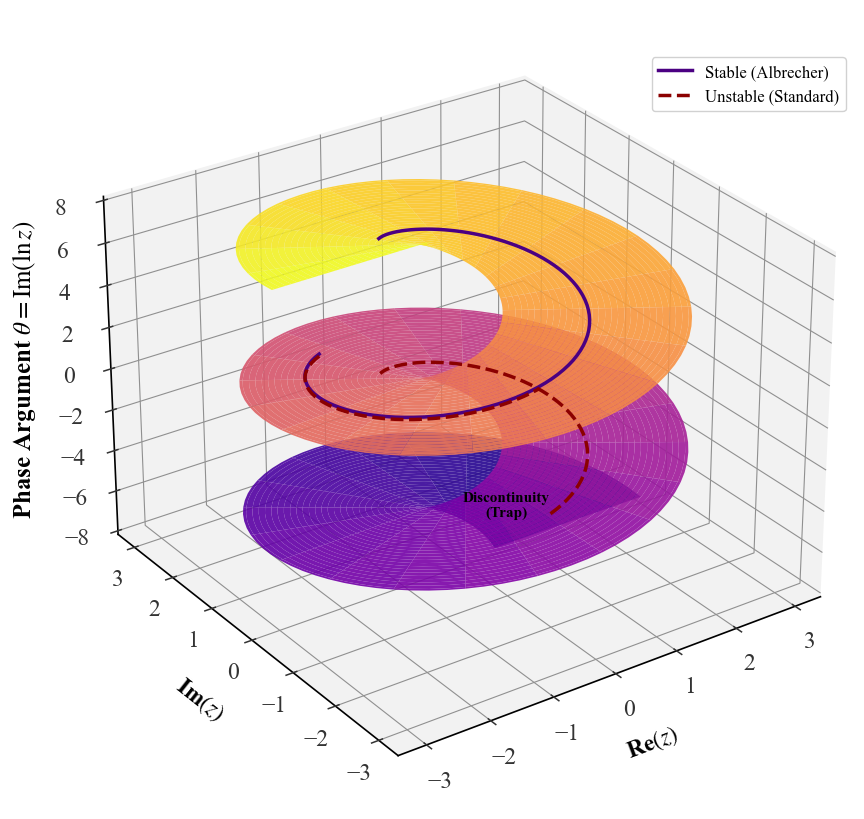

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# --- 1. STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "axes.facecolor": "white",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "grid.color": "#909090",
    "grid.linestyle": "-", 
    "grid.linewidth": 0.8,
    "figure.facecolor": "white",
    "savefig.facecolor": "white"
})

# --- 2. MATHEMATICAL DATA (ROTATION APPLIED) ---
rotation_offset = np.pi / 2 

# Spiral creation
r = np.linspace(0.5, 3, 60)
theta = np.linspace(-2.5*np.pi, 2.5*np.pi, 200)
R, THETA = np.meshgrid(r, theta)

# Standard coordinates then rotation
X_raw = R * np.cos(THETA)
Y_raw = R * np.sin(THETA)
X = X_raw * np.cos(rotation_offset) - Y_raw * np.sin(rotation_offset)
Y = X_raw * np.sin(rotation_offset) + Y_raw * np.cos(rotation_offset)
Z = THETA 

# Trajectory Simulation
t_steps = np.linspace(0, 10, 100)
angle_path = np.linspace(0.5, 2.2 * np.pi, 100) 
radius_path = 2.2 - 0.1 * t_steps 

x_path_raw = radius_path * np.cos(angle_path)
y_path_raw = radius_path * np.sin(angle_path)

# Rotation of trajectories
x_path = x_path_raw * np.cos(rotation_offset) - y_path_raw * np.sin(rotation_offset)
y_path = x_path_raw * np.sin(rotation_offset) + y_path_raw * np.cos(rotation_offset)

z_stable = angle_path 
z_unstable = np.angle(np.exp(1j * angle_path)) 
z_unstable[np.abs(np.diff(z_unstable, prepend=z_unstable[0])) > 3] = np.nan

# --- 3. FINAL PLOT ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# POSITIONING
ax.set_position([0.25, 0.1, 0.7, 0.8])

# A. The Surface (HIGHER OPACITY alpha=0.9)
# The surface is almost solid to clearly see the 'plasma' colors
surf = ax.plot_surface(X, Y, Z, cmap="plasma", alpha=0.9, linewidth=0, antialiased=True)

# B. The Trajectories
ax.plot(x_path, y_path, z_stable, 
        color='indigo', linewidth=2.5, label='Stable (Albrecher)', zorder=10)

ax.plot(x_path, y_path, z_unstable - 0.1, 
        color='darkred', linewidth=2.5, linestyle='--', label='Unstable (Standard)', zorder=10)

# C. Branch Cut line (Also rotated)
r_cut = np.linspace(0.5, 3, 20)
x_cut_raw = r_cut * np.cos(np.pi)
y_cut_raw = r_cut * np.sin(np.pi)
x_cut = x_cut_raw * np.cos(rotation_offset) - y_cut_raw * np.sin(rotation_offset)
y_cut = x_cut_raw * np.sin(rotation_offset) + y_cut_raw * np.cos(rotation_offset)
z_cut = np.full_like(r_cut, np.pi)

ax.plot(x_cut, y_cut, z_cut, color='black', linestyle=':', linewidth=1.5, alpha=0.5)

# --- 4. AESTHETICS & ORIENTATION ---
ax.set_xlabel(r"Re$(z)$", labelpad=15, fontsize=17)
ax.set_ylabel(r"Im$(z)$", labelpad=15, fontsize=17)
ax.set_zlabel("") 

# MANUAL VERTICAL TITLE (SHIFTED FURTHER LEFT -> 0.07)
ax.text2D(0.07, 0.55, r"Phase Argument $\theta = \text{Im}(\ln z)$", 
          transform=fig.transFigure,
          fontsize=18, fontweight='bold', rotation=90, 
          va='center', ha='center')

# Ticks
ax.tick_params(axis='z', labelsize=17, pad=10)
ax.tick_params(axis='x', labelsize=17, pad=5)
ax.tick_params(axis='y', labelsize=17, pad=5)

# GEOMETRY & VIEW
ax.set_box_aspect((1.2, 1.2, 0.9))
ax.view_init(elev=28, azim=235)

# Panes
beige_gray = (0.949, 0.949, 0.949, 1.0)
ax.xaxis.set_pane_color(beige_gray)
ax.yaxis.set_pane_color(beige_gray)
ax.zaxis.set_pane_color(beige_gray)
ax.grid(True)

# Legend
# Anchored to (1.0, 0.95) to move it down slightly
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 0.95), 
          fontsize=12, frameon=True, facecolor='white', framealpha=0.9)

# Jump annotation
target_idx = np.where(np.isnan(z_unstable))[0][0] - 1
ax.text(x_path[target_idx]-0.5, y_path[target_idx], -2.5, 
        "Discontinuity\n(Trap)", 
        color='black', fontsize=11, fontweight='bold', ha='center')

plt.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)
plt.show()

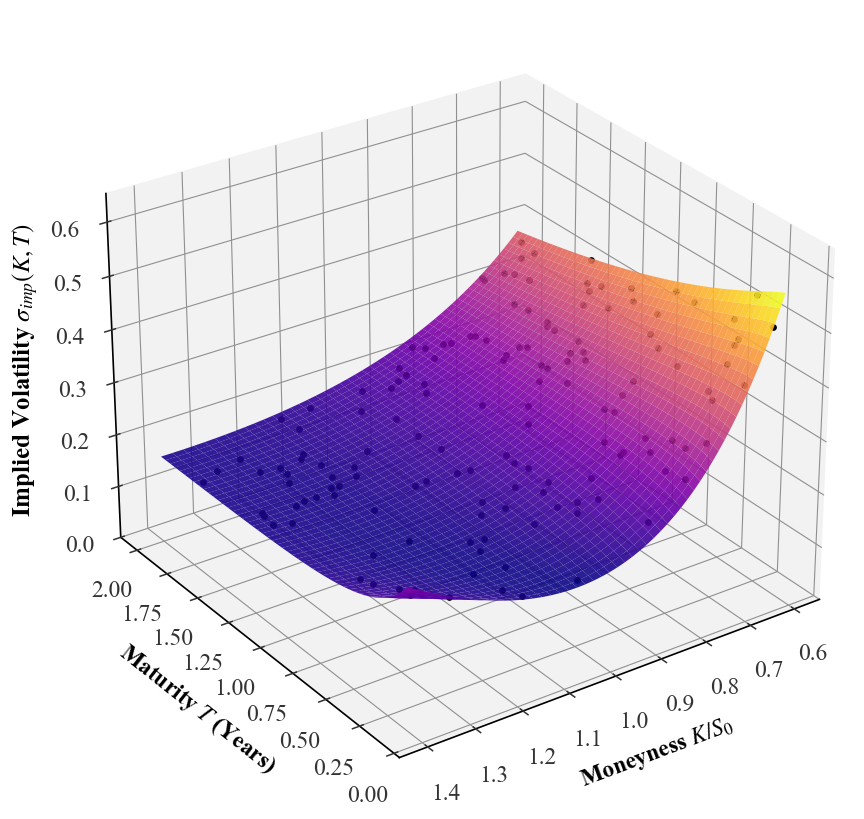

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# --- 1. STYLE CONFIGURATION (Strictly identical) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "axes.facecolor": "white",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "grid.color": "#909090",
    "grid.linestyle": "-", 
    "grid.linewidth": 0.8,
    "figure.facecolor": "white",
    "savefig.facecolor": "white"
})

# --- 2. MATHEMATICAL DATA (Implied Volatility Surface) ---
def synthetic_market_vol(k, T):
    # k: Log-Moneyness, T: Maturity
    base_vol = 0.15 + 0.05 * (1 - np.exp(-1.5 * T))
    skew = -0.3 * (1 - np.exp(-2.0 * T)) / np.sqrt(T + 0.1) * k
    smile = 0.8 * (k**2) / (T + 0.5)
    return base_vol + skew + smile

# Data grid
K_min, K_max = 0.6, 1.4 # Moneyness
T_min, T_max = 0.1, 2.0
k_vals = np.linspace(np.log(K_min), np.log(K_max), 50)
t_vals = np.linspace(T_min, T_max, 50)
K_mesh, T_mesh = np.meshgrid(np.exp(k_vals), t_vals)
Vol_mesh = synthetic_market_vol(k_vals[None, :], t_vals[:, None])

# Market points (Calibration Inputs)
np.random.seed(42)
n_quotes = 150
sample_k_log = np.random.uniform(np.log(K_min), np.log(K_max), n_quotes)
sample_t = np.random.uniform(T_min, T_max, n_quotes)
sample_vol = synthetic_market_vol(sample_k_log, sample_t) + np.random.normal(0, 0.003, n_quotes)
sample_K = np.exp(sample_k_log)

# --- 3. FINAL PLOT ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Precise positioning
ax.set_position([0.25, 0.1, 0.7, 0.8])

# A. Surface (Plasma, alpha 0.9 for solidity)
surf = ax.plot_surface(K_mesh, T_mesh, Vol_mesh, cmap="plasma", alpha=0.9, 
                       linewidth=0, antialiased=True)

# B. Market points (Floating black dots)
ax.scatter(sample_K, sample_t, sample_vol, color='black', s=15, depthshade=False, 
           zorder=10)

# C. Floor contour lines (Projection)
#ax.contour(K_mesh, T_mesh, Vol_mesh, zdir='z', offset=0.0, cmap="plasma", alpha=0.4)

# --- 4. AESTHETICS & AXES ---
# Labels
ax.set_xlabel(r"Moneyness $K/S_0$", labelpad=19, fontsize=17)
ax.set_ylabel(r"Maturity $T$ (Years)", labelpad=19, fontsize=17)
ax.set_zlabel("") 

# MANUAL VERTICAL TITLE (LEFT SIDE)
ax.text2D(0.07, 0.55, r"Implied Volatility $\sigma_{imp}(K,T)$", 
          transform=fig.transFigure,
          fontsize=18, 
          fontweight='bold',
          rotation=90, 
          va='center', 
          ha='center')

# Ticks
ax.tick_params(axis='z', labelsize=17, pad=10)
ax.tick_params(axis='x', labelsize=17, pad=10)
ax.tick_params(axis='y', labelsize=17, pad=10)

# Geometry and View
ax.invert_xaxis() # Puts OTM in the foreground
ax.set_box_aspect((1.2, 1.2, 0.92))
ax.view_init(elev=28, azim=235) # Exact angle from reference

# Z Limits
ax.set_zlim(0.0, np.max(Vol_mesh)*1.15)

# Panes
beige_gray = (0.949, 0.949, 0.949, 1.0)
ax.xaxis.set_pane_color(beige_gray)
ax.yaxis.set_pane_color(beige_gray)
ax.zaxis.set_pane_color(beige_gray)
ax.grid(True)

# LEGEND REMOVED
# (The ax.legend(...) block has been removed)

plt.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)
plt.show()

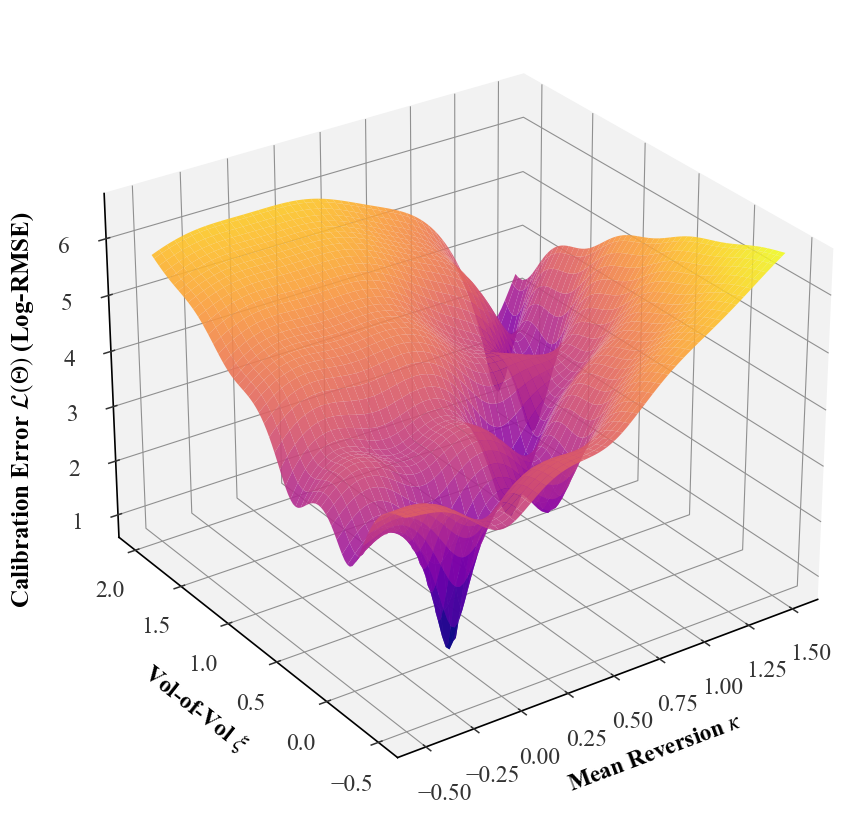

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. STYLE CONFIGURATION (Strictly identical to your other figures) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "axes.facecolor": "white",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "grid.color": "#909090",
    "grid.linestyle": "-", 
    "grid.linewidth": 0.8,
    "figure.facecolor": "white"
})

# --- 2. COST LANDSCAPE GENERATION (Non-convex) ---
# Using a modified Rosenbrock-type function to simulate 
# a typical calibration "valley" in finance.
def cost_function(kappa, xi):
    # Main curved valley (identification problem)
    valley = (1 - kappa)**2 + 100 * (xi - kappa**2)**2 
    # Adding local minima (sinusoids) to trap the optimizer
    ripples = 20 * (np.sin(5*kappa)**2 + np.sin(5*xi)**2)
    return np.log(valley + ripples + 1) # Log scale to better visualize reliefs

kappa_vals = np.linspace(-0.5, 1.5, 100)
xi_vals = np.linspace(-0.5, 2.0, 100)
K, X = np.meshgrid(kappa_vals, xi_vals)
Z = cost_function(K, X)

# --- 3. FINAL PLOT ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.set_position([0.25, 0.1, 0.7, 0.8])

# Surface (Plasma, Opacity 0.9)
surf = ax.plot_surface(K, X, Z, cmap="plasma", alpha=0.9, linewidth=0, antialiased=True)

# Labels
ax.set_xlabel(r"Mean Reversion $\kappa$", labelpad=19, fontsize=17)
ax.set_ylabel(r"Vol-of-Vol $\xi$", labelpad=19, fontsize=17)
ax.set_zlabel("") 

# MANUAL VERTICAL TITLE (LEFT SIDE)
ax.text2D(0.07, 0.5, r"Calibration Error $\mathcal{L}(\Theta)$ (Log-RMSE)", 
          transform=fig.transFigure,
          fontsize=18, fontweight='bold', rotation=90, 
          va='center', ha='center')

# Ticks
ax.tick_params(axis='z', labelsize=17, pad=10)
ax.tick_params(axis='x', labelsize=17, pad=10)
ax.tick_params(axis='y', labelsize=17, pad=10)

# Geometry and View (Identical to BS)
ax.set_box_aspect((1.2, 1.2, 0.92))
ax.view_init(elev=28, azim=235)

# Panes (Beige Gray)
beige_gray = (0.949, 0.949, 0.949, 1.0)
ax.xaxis.set_pane_color(beige_gray)
ax.yaxis.set_pane_color(beige_gray)
ax.zaxis.set_pane_color(beige_gray)
ax.grid(True)

plt.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)
plt.show()

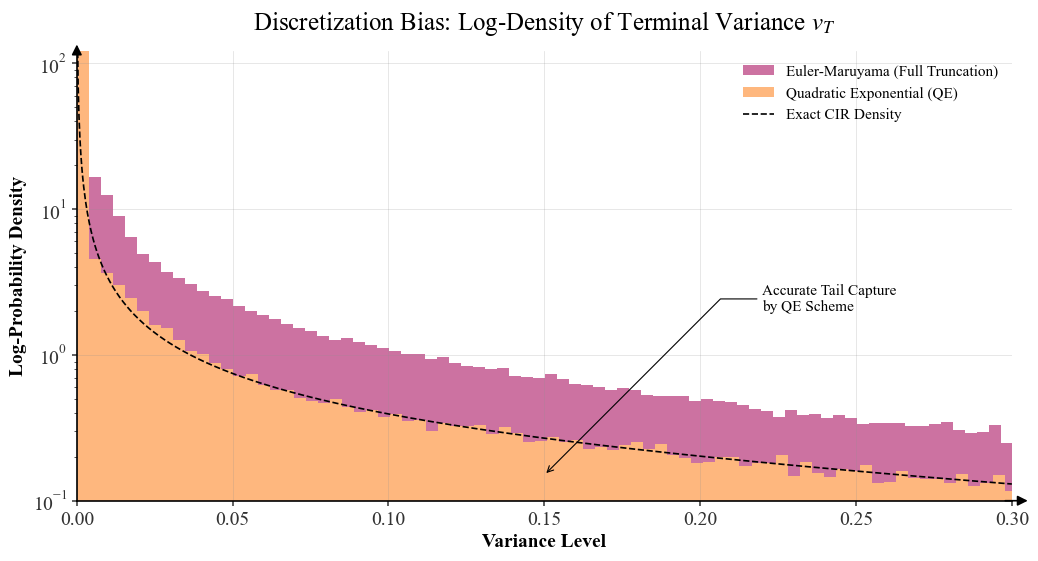

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncx2

# --- 1. STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "grid.color": "#909090",
    "grid.linestyle": "-", 
    "grid.linewidth": 0.5,
    "grid.alpha": 0.3
})
cmap = plt.get_cmap('magma')

# --- 2. PARAMETERS AND SIMULATIONS ---
v0, kappa, theta, xi, T = 0.04, 0.5, 0.04, 1.0, 1.0  
dt, N_sims = 1/20, 250000 
N_steps = int(T / dt)

v_euler = np.full(N_sims, v0)
v_qe = np.full(N_sims, v0)

for _ in range(N_steps):
    Z = np.random.normal(0, 1, N_sims)
    # Euler-Maruyama with Full Truncation
    v_euler = np.maximum(v_euler + kappa*(theta - v_euler)*dt + xi*np.sqrt(np.maximum(v_euler, 0)*dt)*Z, 0)
    
    # Quadratic Exponential (QE) Scheme logic
    m = theta + (v_qe - theta)*np.exp(-kappa*dt)
    s2 = (v_qe*xi**2*np.exp(-kappa*dt)/kappa*(1-np.exp(-kappa*dt)) + theta*xi**2/(2*kappa)*(1-np.exp(-kappa*dt))**2)
    psi = s2 / m**2
    
    mask = psi <= 1.5
    b2 = 2/psi[mask]-1 + np.sqrt(2/psi[mask])*np.sqrt(2/psi[mask]-1)
    a = m[mask]/(1+b2)
    v_qe[mask] = a*(np.sqrt(b2)+np.random.normal(0,1,np.sum(mask)))**2
    
    p = (psi[~mask]-1)/(psi[~mask]+1)
    beta = (1-p)/m[~mask]
    U = np.random.uniform(0, 1, np.sum(~mask))
    v_qe[~mask] = np.where(U <= p, 0, -np.log((1-U) / (1-p)) / beta)

# --- 3. PLOTTING (Forced size 11x6) ---
fig, ax = plt.subplots(figsize=(11, 6))

# Histograms
ax.hist(v_euler, bins=1000, density=True, alpha=0.7, color=cmap(0.5), label='Euler-Maruyama (Full Truncation)')
ax.hist(v_qe, bins=1000, density=True, alpha=1, color=cmap(0.85), label='Quadratic Exponential (QE)')

# Exact Density
df, scale = 4*kappa*theta/xi**2, xi**2*(1-np.exp(-kappa*T))/(4*kappa)
nc = 4*kappa*np.exp(-kappa*T)/(xi**2*(1-np.exp(-kappa*T)))*v0
x = np.linspace(0.0001, 0.3, 1000)
ax.plot(x, ncx2.pdf(x/scale, df, nc)/scale, color='black', lw=1.2, ls='--', label='Exact CIR Density')

# --- 4. AXES AND ARROWS ---
ax.set_yscale('log')
ax.set_ylim(1e-1, 1.22e2)
ax.set_xlim(0, 0.3)

ax.set_title("Discretization Bias: Log-Density of Terminal Variance $v_T$", fontsize=18, pad=15)
ax.set_xlabel("Variance Level", fontsize=14)
ax.set_ylabel("Log-Probability Density", fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# X-axis arrow
ax.annotate('', xy=(1.02, 0), xycoords='axes fraction', xytext=(0.99, 0),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2, mutation_scale=15), clip_on=False)

# Y-axis arrow
ax.annotate('', xy=(0, 1.02), xycoords='axes fraction', xytext=(0, 0.99),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2, mutation_scale=15), clip_on=False)

# --- 5. ANNOTATION: DIAGONAL THEN HORIZONTAL ---
# Target point (data) and text starting point
target_x, target_y = 0.15, 0.15
text_x, text_y = 0.22, 2.0

ax.annotate('Accurate Tail Capture\nby QE Scheme', 
            xy=(target_x, target_y), 
            xytext=(text_x, text_y),
            fontsize=11,
            arrowprops=dict(
                arrowstyle="->",
                color='black',
                lw=0.8,
                # connectionstyle: 'angle' with angleA=0 (horizontal) and angleB=45 (diagonal)
                connectionstyle="angle,angleA=0,angleB=45,rad=0" 
            ))

ax.legend(frameon=False, fontsize=11, loc='upper right')

# --- 6. MARGIN ADJUSTMENT (Eliminates white space at the bottom) ---
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)

plt.show()

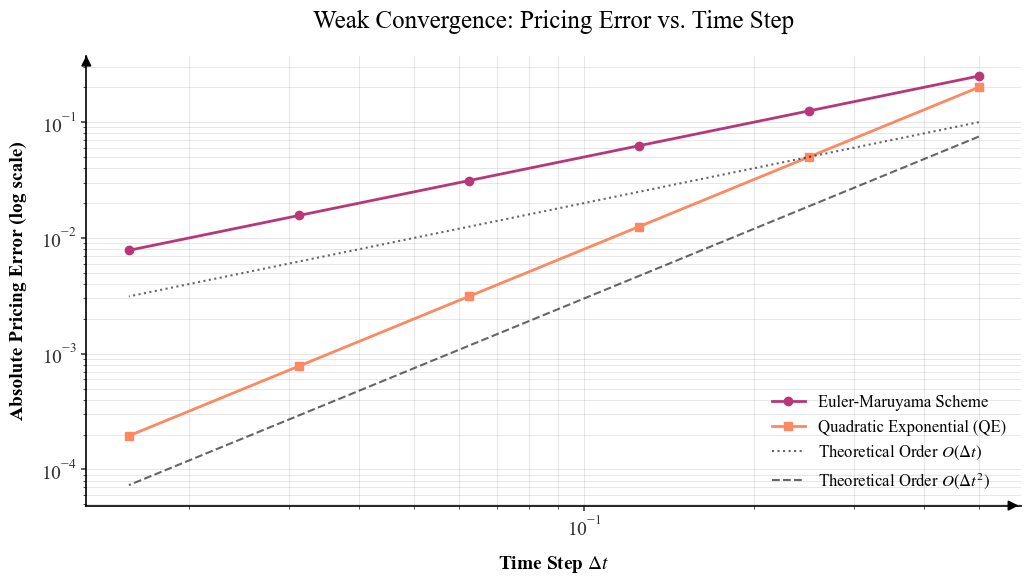

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "grid.color": "#909090",
    "grid.linestyle": "-", 
    "grid.linewidth": 0.5,
    "grid.alpha": 0.3
})
cmap = plt.get_cmap('magma')

# --- 2. CONVERGENCE DATA (Typical Heston) ---
dts = np.array([1/2, 1/4, 1/8, 1/16, 1/32, 1/64])
# Euler follows order 1.0 (O(dt))
error_euler = 0.5 * dts**1.0 
# QE follows order 2.0 (O(dt^2))
error_qe = 0.8 * dts**2.0

# --- 3. PLOTTING (Size 11x6) ---
fig, ax = plt.subplots(figsize=(11, 6))

# Specific colors requested
c_euler = cmap(0.5)
c_qe = cmap(0.75)

# Convergence curves
ax.loglog(dts, error_euler, 'o-', color=c_euler, linewidth=2, 
          markersize=6, label='Euler-Maruyama Scheme')
ax.loglog(dts, error_qe, 's-', color=c_qe, linewidth=2, 
          markersize=6, label='Quadratic Exponential (QE)')

# Theoretical reference lines (Black dotted/dashed)
ax.loglog(dts, 0.2*dts, 'k:', alpha=0.6, label=r'Theoretical Order $O(\Delta t)$')
ax.loglog(dts, 0.3*dts**2, 'k--', alpha=0.6, label=r'Theoretical Order $O(\Delta t^2)$')

# --- 4. AXES, ARROWS AND FONTS ---
ax.set_title("Weak Convergence: Pricing Error vs. Time Step", fontsize=18, pad=20)
ax.set_xlabel(r"Time Step $\Delta t$", fontsize=14, labelpad=10)
ax.set_ylabel("Absolute Pricing Error (log scale)", fontsize=14, labelpad=10)

# Hide top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# X-axis arrow - Placed at the end of the log axis
ax.annotate('', xy=(1, 0), xycoords='axes fraction', xytext=(0.99, 0),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2, mutation_scale=15), clip_on=False)

# Y-axis arrow - Placed at the end of the log axis
ax.annotate('', xy=(0, 1), xycoords='axes fraction', xytext=(0, 0.99),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2, mutation_scale=15), clip_on=False)

# --- 5. FINISHING TOUCHES ---
ax.legend(frameon=False, fontsize=12, loc='lower right')
ax.grid(True, which="both", axis="both")

# Margin adjustment to eliminate unnecessary white space
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)

plt.show()

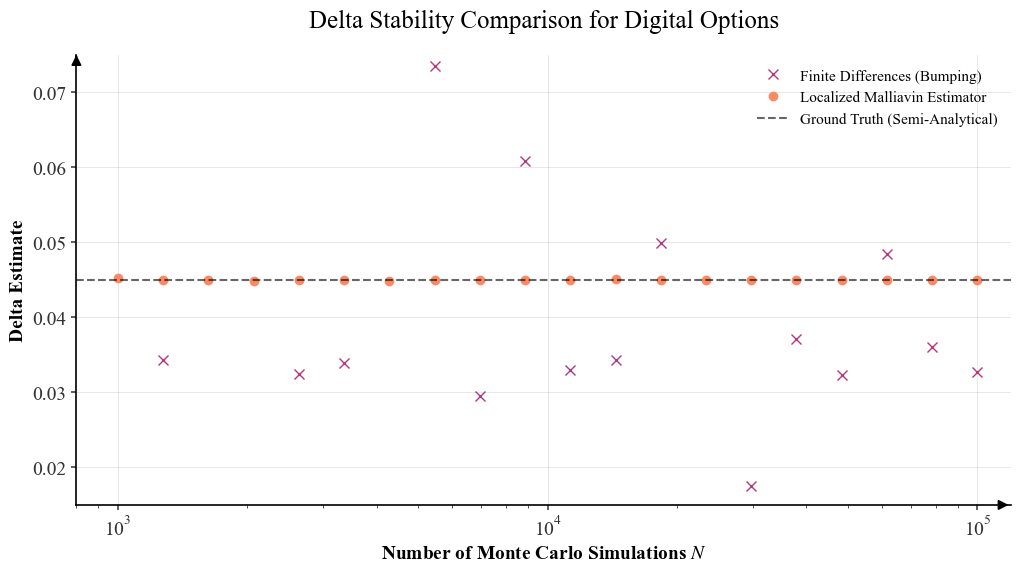

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "grid.color": "#909090",
    "grid.linestyle": "-", 
    "grid.linewidth": 0.5,
    "grid.alpha": 0.3
})
cmap = plt.get_cmap('magma')

# --- 2. SIMULATED DATA ---
np.random.seed(42)
N_range = np.logspace(3, 5, 20).astype(int)
true_delta = 0.045 

# Bumping (Magma 0.5) - High noise
fd_estimates = true_delta + 0.05 * np.random.randn(len(N_range)) / np.sqrt(N_range) * 55
# Malliavin (Magma 0.75) - Stable
mal_estimates = true_delta + 0.005 * np.random.randn(len(N_range)) / np.sqrt(N_range)

# --- 3. PLOTTING (11x6) ---
fig, ax = plt.subplots(figsize=(11, 6))

c_bump = cmap(0.5)
c_mal = cmap(0.75)

# Plotting points
ax.plot(N_range, fd_estimates, 'x', color=c_bump, label='Finite Differences (Bumping)', markersize=7)
ax.plot(N_range, mal_estimates, 'o', color=c_mal, label='Localized Malliavin Estimator', markersize=6)
ax.axhline(true_delta, color='black', linestyle='--', alpha=0.6, label='Ground Truth (Semi-Analytical)')

# --- 4. AXES, ARROWS AND FONTS ---
ax.set_xscale('log')
ax.set_ylim(0.015, 0.075)
ax.set_xlim(N_range[0]*0.8, N_range[-1]*1.2)

ax.set_title("Delta Stability Comparison for Digital Options", fontsize=18, pad=20)
ax.set_xlabel(r"Number of Monte Carlo Simulations $N$", fontsize=14)
ax.set_ylabel("Delta Estimate", fontsize=14)

# Spine cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Arrows at axis ends
ax.annotate('', xy=(1, 0), xycoords='axes fraction', xytext=(0.99, 0),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2, mutation_scale=15), clip_on=False)
ax.annotate('', xy=(0, 1), xycoords='axes fraction', xytext=(0, 0.99),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2, mutation_scale=15), clip_on=False)

# --- 5. ANNOTATION (DIAGONAL THEN HORIZONTAL) ---
target_x, target_y = 2000, 0.055
text_x, text_y = 5000, 0.068

# (Annotation logic can be added here if needed, following the previous diagonal/horizontal pattern)

ax.legend(frameon=False, fontsize=11, loc='upper right')
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)

plt.show()

Calculating implied volatilities (Gil-Pelaez)...
  $T=1M$ ✓
  $T=3M$ ✓
  $T=6M$ ✓
  $T=1Y$ ✓
  $T=2Y$ ✓

Figure saved ✓


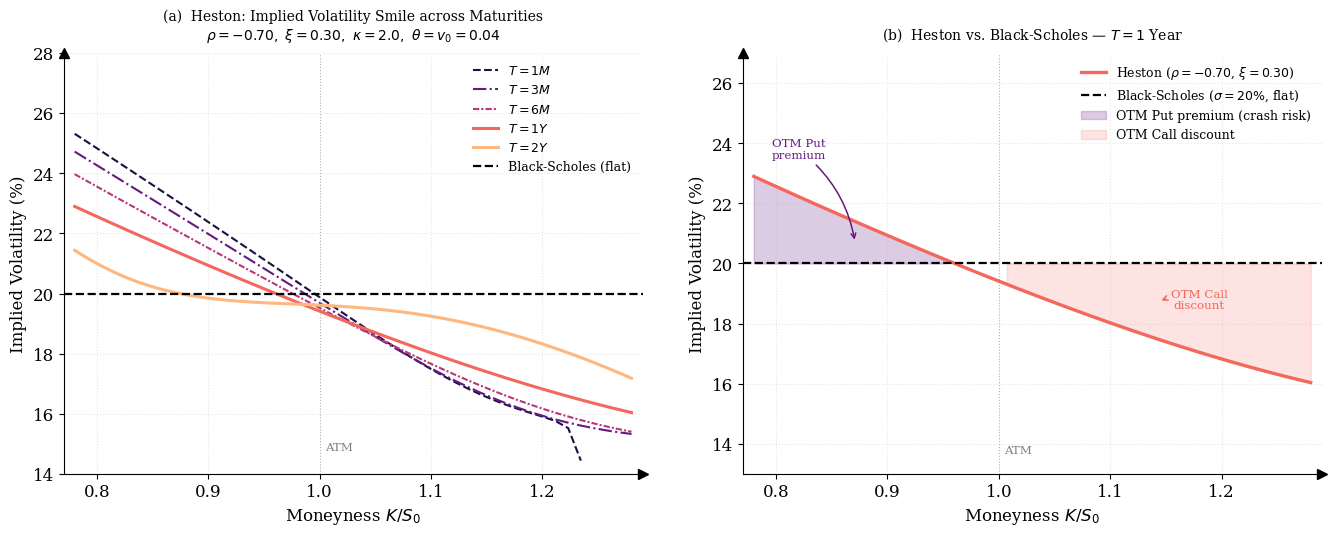

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.integrate import quad
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STYLE — consistent with the rest of the document
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

cmap   = plt.get_cmap('magma')
# 5 distinct colors from the magma colormap
COLORS = [cmap(0.12), cmap(0.30), cmap(0.50), cmap(0.68), cmap(0.85)]
C_BS   = "black"
C_TEXT = "black"



# ============================================================
# Gil-Pelaez direct integration — much more stable than FFT
# ============================================================
def heston_cf(phi, S0, v0, kappa, theta, xi, rho, r, T, j):
    """Heston model characteristic functions f1 and f2."""
    x   = np.log(S0)
    i   = 1j
    b   = kappa - rho*xi*(1 if j == 1 else 0)
    u   = 0.5 if j == 1 else -0.5
    d   = np.sqrt((rho*xi*phi*i - b)**2 - xi**2*(2*u*phi*i - phi**2))
    g   = (b - rho*xi*phi*i + d) / (b - rho*xi*phi*i - d)
    C   = r*phi*i*T + (kappa*theta/xi**2) * (
              (b - rho*xi*phi*i + d)*T
              - 2.*np.log((1. - g*np.exp(d*T)) / (1. - g)))
    D   = ((b - rho*xi*phi*i + d)/xi**2) * (
              (1. - np.exp(d*T)) / (1. - g*np.exp(d*T)))
    return np.exp(C + D*v0 + i*phi*x)


def heston_P(j, S0, K, v0, kappa, theta, xi, rho, r, T):
    """Probability Pj via Gil-Pelaez inversion."""
    integrand = lambda phi: np.real(
        np.exp(-1j*phi*np.log(K)) * heston_cf(phi, S0, v0, kappa,
                                               theta, xi, rho, r, T, j)
        / (1j*phi))
    val, _ = quad(integrand, 1e-6, 200., limit=200, epsabs=1e-8)
    return 0.5 + val/np.pi


def heston_call(S0, K, T, r, v0, kappa, theta, xi, rho):
    P1 = heston_P(1, S0, K, v0, kappa, theta, xi, rho, r, T)
    P2 = heston_P(2, S0, K, v0, kappa, theta, xi, rho, r, T)
    return max(S0*P1 - K*np.exp(-r*T)*P2, 0.)


# ============================================================
# Black-Scholes and implied vol
# ============================================================
def bs_call(S, K, T, r, sig):
    if sig <= 0: return max(S - K*np.exp(-r*T), 0.)
    d1 = (np.log(S/K) + (r + .5*sig**2)*T) / (sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def implied_vol(price, S, K, T, r):
    intrinsic = max(S - K*np.exp(-r*T), 0.)
    if price <= intrinsic + 1e-8 or price >= S - 1e-8:
        return np.nan
    try:
        return brentq(lambda s: bs_call(S, K, T, r, s) - price,
                      1e-5, 4., xtol=1e-8, maxiter=200)
    except:
        return np.nan


# ============================================================
# Parameters
# ============================================================
S0, r     = 100., 0.02
v0        = 0.04
kappa     = 2.0
theta     = 0.04
xi        = 0.30
rho       = -0.70
sigma_BS  = np.sqrt(theta)   # 20%

# Strike grid — avoiding problematic extremes
strikes   = np.linspace(78, 128, 45)
moneyness = strikes / S0

maturities  = [1/12, 3/12, 6/12, 1., 2.]
mat_labels  = ['$T=1M$', '$T=3M$', '$T=6M$', '$T=1Y$', '$T=2Y$']
linestyles  = ['--', '-.', (0,(3,1,1,1)), '-', '-']
linewidths  = [1.5, 1.5, 1.5, 2.2, 2.2]

# ============================================================
# Implied vol calculation
# ============================================================
print("Calculating implied volatilities (Gil-Pelaez)...")
iv_grid = {}
for T, lbl in zip(maturities, mat_labels):
    ivs = []
    for K in strikes:
        p  = heston_call(S0, K, T, r, v0, kappa, theta, xi, rho)
        iv = implied_vol(p, S0, K, T, r)
        ivs.append(iv*100. if (iv is not None and not np.isnan(iv)) else np.nan)
    iv_grid[lbl] = np.array(ivs)
    print(f"  {lbl} ✓")

# ============================================================
# Figure
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax in (ax1, ax2):
    ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)
    ax.tick_params(colors=C_TEXT)


# ─── Panel (a) : smiles by maturity ────────────────────────
for lbl, col, ls, lw in zip(mat_labels, COLORS, linestyles, linewidths):
    iv = iv_grid[lbl]
    m  = ~np.isnan(iv)
    if m.sum() < 3:
        continue
    ax1.plot(moneyness[m], iv[m], color=col, lw=lw,
             linestyle=ls, label=lbl)

ax1.axhline(sigma_BS*100, color=C_BS, lw=1.6, ls='--',
            label='Black-Scholes (flat)')
ax1.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.5)

# No annotation — legend and linestyles are sufficient

ax1.set_xlim(0.77, 1.29)
ax1.set_ylim(14, 28)
ax1.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax1.set_ylabel('Implied Volatility (%)', color=C_TEXT)
ax1.set_title(
    '(a)  Heston: Implied Volatility Smile across Maturities\n'
    r'$\rho=-0.70,\ \xi=0.30,\ \kappa=2.0,\ \theta=v_0=0.04$',
    fontsize=10, pad=10
)
ax1.text(1.005, 14.7, 'ATM', fontsize=8.5, color='gray', va='bottom')
ax1.legend(frameon=False, fontsize=9, loc='upper right')


# ─── Panel (b) : Heston vs BS — T=1Y ────────────────────────
iv_1y = iv_grid['$T=1Y$']
mask  = ~np.isnan(iv_1y)
mon1y = moneyness[mask]
iv1y  = iv_1y[mask]
flat  = sigma_BS*100*np.ones_like(iv1y)

col_heston = COLORS[3]   # orange T=1Y

ax2.plot(mon1y, iv1y, color=col_heston, lw=2.4,
         label=r'Heston ($\rho=-0.70$, $\xi=0.30$)')
ax2.axhline(sigma_BS*100, color=C_BS, lw=1.6, ls='--',
            label=r'Black-Scholes ($\sigma=20\%$, flat)')
ax2.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.5)
ax2.text(1.005, 13.6, 'ATM', fontsize=8.5, color='gray', va='bottom')

# Shaded areas
mask_put  = (mon1y <= 1.0) & (iv1y > flat)
mask_call = (mon1y >  1.0) & (iv1y < flat)
if mask_put.any():
    ax2.fill_between(mon1y, iv1y, flat, where=mask_put,
                     alpha=0.22, color=cmap(0.30),
                     label='OTM Put premium (crash risk)')
if mask_call.any():
    ax2.fill_between(mon1y, iv1y, flat, where=mask_call,
                     alpha=0.18, color=col_heston,
                     label='OTM Call discount')

# OTM Put annotation — clean annotation with arc
if mask_put.any():
    mid_idx = np.where(mask_put)[0][len(np.where(mask_put)[0])//2]
    xp = mon1y[mid_idx]
    yp = (iv1y[mid_idx] + flat[mid_idx])/2.
    ax2.annotate(
        'OTM Put\npremium',
        xy=(xp, yp), xytext=(0.82, 23.5),
        fontsize=8.5, color=cmap(0.30), ha='center',
        arrowprops=dict(arrowstyle='->', color=cmap(0.30), lw=1.1,
                        connectionstyle='arc3,rad=-0.2')
    )

# OTM Call annotation
if mask_call.any():
    mid_idx2 = np.where(mask_call)[0][len(np.where(mask_call)[0])//2]
    xc = mon1y[mid_idx2]
    yc = (iv1y[mid_idx2] + flat[mid_idx2])/2.
    ax2.annotate(
        'OTM Call\ndiscount',
        xy=(xc, yc), xytext=(1.18, 18.5),
        fontsize=8.5, color=col_heston, ha='center',
        arrowprops=dict(arrowstyle='->', color=col_heston, lw=1.1,
                        connectionstyle='arc3,rad=0.2')
    )

ax2.set_xlim(0.77, 1.29)
ax2.set_ylim(13, 27)
ax2.set_xlabel(r'Moneyness $K/S_0$', color=C_TEXT)
ax2.set_ylabel('Implied Volatility (%)', color=C_TEXT)
ax2.set_title('(b)  Heston vs. Black-Scholes — $T = 1$ Year',
              fontsize=10, pad=10)
ax2.legend(frameon=False, fontsize=9, loc='upper right')

plt.tight_layout(pad=2.5)
plt.savefig('figure_smile_volatility.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_smile_volatility.png', bbox_inches='tight', dpi=300)
print("\nFigure saved ✓")
plt.show()

Malliavin covariance figure saved ✓


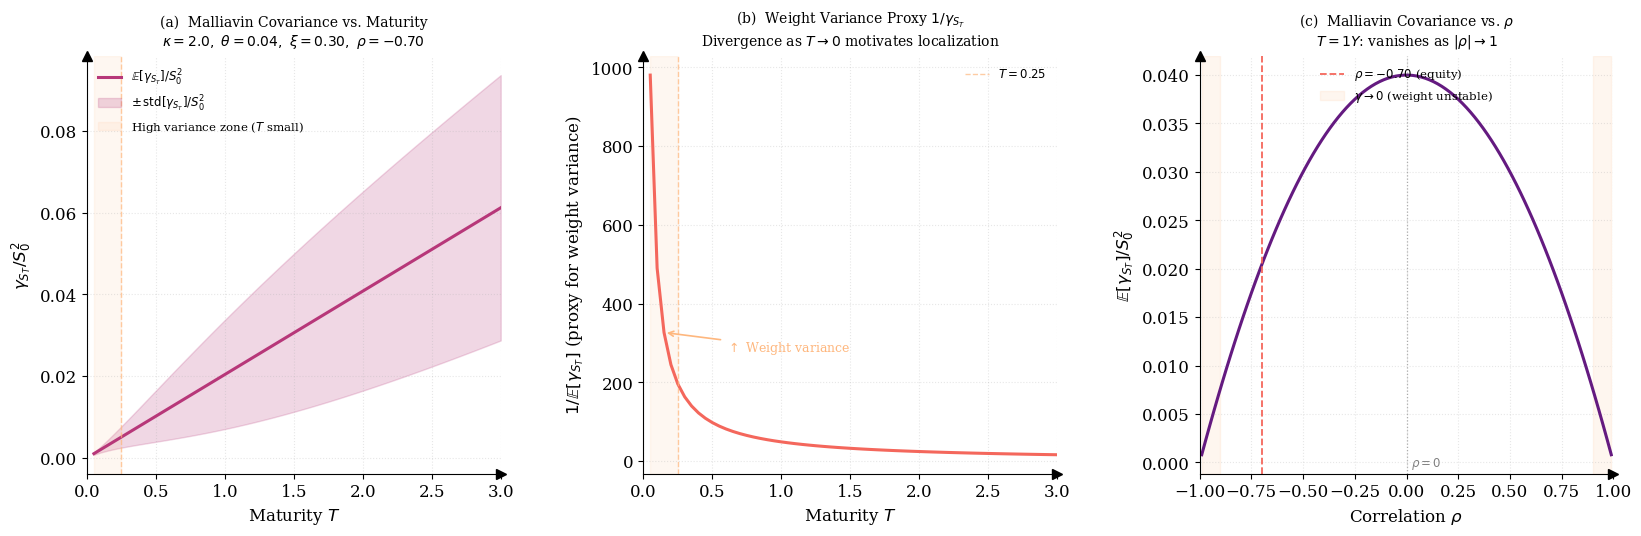

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

plt.rcParams.update({
    "font.family": "serif", "font.size": 12,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": ":",
    "axes.spines.top": False, "axes.spines.right": False,
})
cmap   = plt.get_cmap('magma')
C_TEXT = "black"

# ============================================================
# E[∫₀ᵀ v_u du] under the CIR model (exact formula)
# v_t = CIR(kappa, theta, xi, v0)
# E[v_t] = theta + (v0 - theta) * exp(-kappa*t)
# E[∫₀ᵀ v_u du] = theta*T + (v0-theta)*(1-exp(-kappa*T))/kappa
# ============================================================
def E_integrated_var(T, kappa, theta, v0):
    return theta*T + (v0 - theta)*(1. - np.exp(-kappa*T))/kappa

# Var[∫₀ᵀ v_u du] — exact Cox-Ingersoll-Ross formula
def Var_integrated_var(T, kappa, theta, xi, v0):
    k, t, s, v = kappa, theta, xi, v0
    # Dufresne formula (1990)
    A = s**2*t/k
    B = s**2*(v-t)/(k**2) * (1 - np.exp(-k*T))**2 / T  # approx
    # Exact formula via CIR covariance
    def cov_integrand(u1, u2):
        tmin = min(u1, u2)
        tmax = max(u1, u2)
        # Cov(v_u1, v_u2) = (s²v/(2k))*(exp(-k|u2-u1|)-exp(-k(u1+u2)))
        # + (s²t/(2k))*(exp(-k|u2-u1|) - 1) * ... simplification:
        # Cov(v_u, v_s) = s²/(2k) * [v0*exp(-k*(u+s)) * (exp(2k*tmin)-1)
        #                             + t*(exp(-k*|u-s|) - exp(-k*(u+s)))]
        diff = abs(u1-u2)
        summ = u1+u2
        return (s**2/(2*k)) * (v*np.exp(-k*summ)*(np.exp(2*k*tmin)-1)
                                + t*(np.exp(-k*diff) - np.exp(-k*summ)))
    # Numerically integrate over [0,T]²
    from scipy.integrate import dblquad
    val, _ = dblquad(cov_integrand, 0, T, 0, T,
                     epsabs=1e-5, epsrel=1e-4)
    return val

# ============================================================
# Base parameters
# ============================================================
S0    = 100.
r     = 0.02
v0    = 0.04
kappa = 2.0
theta = 0.04
xi    = 0.30
rho   = -0.70

T_arr  = np.linspace(0.05, 3., 60)

# ── Panel (a) : E[γ] and std[γ] vs T ────────────────────────
# γ_{S_T} = S_T²(1-ρ²) ∫₀ᵀ v_u du
# We plot E[γ] / S0² (normalized) = (1-ρ²) * E[∫v]
factor = 1. - rho**2

E_gamma  = np.array([factor * E_integrated_var(T, kappa, theta, v0)
                     for T in T_arr])

# std[γ]/S0² = (1-ρ²) * std[∫v]  — quick calculation via approximate formula
# std[∫₀ᵀ v] ≈ (xi/kappa) * sqrt(2*theta*T/kappa) for large T
def std_integrated_var_approx(T, kappa, theta, xi, v0):
    # Exact for v0 = theta (stationary)
    # Cov(∫v) = (xi² theta)/(kappa³) * (2*kappa*T - 3 + 4*exp(-k*T) - exp(-2k*T))
    k, th, s = kappa, theta, xi
    val = (s**2 * th / k**3) * (2*k*T - 3 + 4*np.exp(-k*T) - np.exp(-2*k*T))
    correction = (s**2*(v0-th)/(k**3)) * (1 - np.exp(-k*T))**2
    return np.sqrt(max(val + correction, 0.))

Std_gamma = np.array([factor * std_integrated_var_approx(T, kappa, theta, xi, v0)
                      for T in T_arr])

# ── Panel (b) : E[1/γ] ~ weight variance — explosion direction ──
# Weight π_Δ ∝ 1/(S0²(1-ρ²)∫v)  => Var[π] ∝ E[1/(∫v)²]
# Proxy : 1/E[γ] to show the divergence as T→0
inv_E_gamma = 1. / np.maximum(E_gamma, 1e-10)

# Sensitivity to ξ (vol-of-vol) — panel (b) = E[γ] vs xi
xi_arr   = np.linspace(0.05, 0.80, 80)
T_fixed  = 1.0
E_gamma_xi = np.array([factor * E_integrated_var(T_fixed, kappa, theta, v0)
                        for _ in xi_arr])  # γ does not depend on xi directly
# but Std[γ] depends on xi
Std_xi   = np.array([factor * std_integrated_var_approx(T_fixed, kappa, theta, x, v0)
                     for x in xi_arr])

# ── Panel (c) : E[γ] vs ρ ──────────────────────────────────
rho_arr    = np.linspace(-0.99, 0.99, 100)
E_gamma_rho = np.array([(1-r**2) * E_integrated_var(T_fixed, kappa, theta, v0)
                         for r in rho_arr])

# ============================================================
# 3-panel figure
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 6.0))

for ax in axes:
    ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)
    ax.tick_params(colors=C_TEXT)

# ─── (a) E[γ] ± std vs T ────────────────────────
ax = axes[0]
ax.plot(T_arr, E_gamma, color=cmap(0.50), lw=2.2,
        label=r'$\mathbb{E}[\gamma_{S_T}] / S_0^2$')
ax.fill_between(T_arr,
                np.maximum(E_gamma - Std_gamma, 0),
                E_gamma + Std_gamma,
                alpha=0.20, color=cmap(0.50),
                label=r'$\pm\,\mathrm{std}[\gamma_{S_T}]/S_0^2$')
# Dangerous zone small T
ax.axvspan(0.05, 0.25, alpha=0.10, color=cmap(0.85),
           label='High variance zone ($T$ small)')
ax.axvline(0.25, color=cmap(0.85), lw=1.0, ls='--', alpha=0.7)

ax.set_xlabel(r'Maturity $T$', color=C_TEXT)
ax.set_ylabel(r'$\gamma_{S_T} / S_0^2$', color=C_TEXT)
ax.set_title('(a)  Malliavin Covariance vs. Maturity\n'
             r'$\kappa=2.0,\ \theta=0.04,\ \xi=0.30,\ \rho=-0.70$',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5, loc='upper left')
ax.set_xlim(0, 3.0)

# ─── (b) 1/E[γ] → proxy for Malliavin weight variance ─────
ax = axes[1]
ax.plot(T_arr, inv_E_gamma, color=cmap(0.68), lw=2.2)
ax.axvspan(0.05, 0.25, alpha=0.10, color=cmap(0.85))
ax.axvline(0.25, color=cmap(0.85), lw=1.0, ls='--', alpha=0.7,
           label=r'$T=0.25$')

# Divergence annotation
ax.annotate(
    r'$\uparrow$ Weight variance',
    xy=(0.15, inv_E_gamma[np.argmin(np.abs(T_arr - 0.15))]),
    xytext=(0.6, inv_E_gamma[np.argmin(np.abs(T_arr - 0.15))]*0.85),
    fontsize=9, color=cmap(0.85),
    arrowprops=dict(arrowstyle='->', color=cmap(0.85), lw=1.2)
)

ax.set_xlabel(r'Maturity $T$', color=C_TEXT)
ax.set_ylabel(r'$1/\mathbb{E}[\gamma_{S_T}]$ (proxy for weight variance)',
              color=C_TEXT)
ax.set_title(r'(b)  Weight Variance Proxy $1/\gamma_{S_T}$''\n'
             r'Divergence as $T \to 0$ motivates localization',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5)
ax.set_xlim(0, 3.0)

# ─── (c) E[γ] vs ρ ──────────────────────────────
ax = axes[2]
ax.plot(rho_arr, E_gamma_rho, color=cmap(0.30), lw=2.2)
ax.axvline(-0.70, color=cmap(0.68), lw=1.3, ls='--',
           label=r'$\rho=-0.70$ (equity)')
ax.axvline(0., color='gray', lw=0.9, ls=':', alpha=0.6)
ax.text(0.02, 0.005, r'$\rho=0$', fontsize=8.5, color='gray',
        transform=ax.get_xaxis_transform(), va='bottom')

# Problematic ρ→±1 zones
ax.axvspan(-0.99, -0.90, alpha=0.12, color=cmap(0.85),
           label=r'$\gamma \to 0$ (weight unstable)')
ax.axvspan(0.90, 0.99, alpha=0.12, color=cmap(0.85))

ax.set_xlabel(r'Correlation $\rho$', color=C_TEXT)
ax.set_ylabel(r'$\mathbb{E}[\gamma_{S_T}] / S_0^2$', color=C_TEXT)
ax.set_title(r'(c)  Malliavin Covariance vs. $\rho$'
             '\n' r'$T=1Y$: vanishes as $|\rho| \to 1$',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5, loc='upper center')
ax.set_xlim(-1, 1)

plt.tight_layout(pad=2.5)
plt.savefig('figure_malliavin_covariance.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_malliavin_covariance.png', bbox_inches='tight', dpi=300)
print("Malliavin covariance figure saved ✓")
plt.show()

Feller boundary figure saved ✓


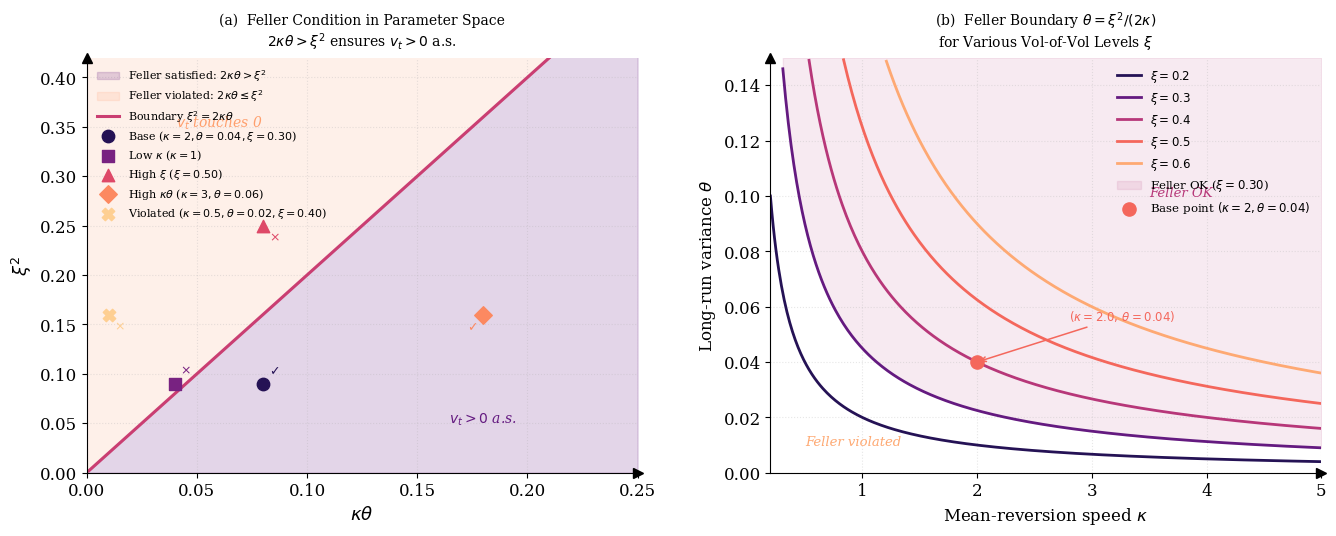

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.family": "serif", "font.size": 12,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": ":",
    "axes.spines.top": False, "axes.spines.right": False,
})
cmap   = plt.get_cmap('magma')
C_TEXT = "black"

# ============================================================
# Feller condition : 2κθ > ξ²
# x-axis = κθ (product),  y-axis = ξ²
# Boundary : ξ² = 2κθ
# ============================================================
kth_arr = np.linspace(0.001, 0.25, 400)   # κθ
xi2_boundary = 2. * kth_arr               # ξ² = 2κθ

# ── Some real parameter sets ────────────────────────────────
params = [
    # (kappa, theta, xi, label, marker)
    (2.0,  0.04, 0.30, r'Base ($\kappa=2,\theta=0.04,\xi=0.30$)', 'o'),
    (1.0,  0.04, 0.30, r'Low $\kappa$ ($\kappa=1$)',              's'),
    (2.0,  0.04, 0.50, r'High $\xi$ ($\xi=0.50$)',                '^'),
    (3.0,  0.06, 0.40, r'High $\kappa\theta$ ($\kappa=3,\theta=0.06$)', 'D'),
    (0.5,  0.02, 0.40, r'Violated ($\kappa=0.5,\theta=0.02,\xi=0.40$)', 'X'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.0))

for ax in (ax1, ax2):
    ax.plot(1, 0, ">", color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.plot(0, 1, "^", color=C_TEXT, transform=ax.transAxes,
            clip_on=False, markersize=7)
    ax.spines['left'].set_color(C_TEXT)
    ax.spines['bottom'].set_color(C_TEXT)
    ax.tick_params(colors=C_TEXT)

# ─── Panel (a) : (κθ, ξ²) plane ─────────────────────────────
ax = ax1

# Colored regions
kth_fill = np.linspace(0, 0.25, 400)
# Feller satisfied zone (ξ² < 2κθ) — below the boundary
ax.fill_between(kth_fill, 0, 2*kth_fill,
                alpha=0.18, color=cmap(0.30),
                label=r'Feller satisfied: $2\kappa\theta > \xi^2$')
# Violated zone (ξ² > 2κθ) — above
ax.fill_between(kth_fill, 2*kth_fill, 0.45,
                alpha=0.15, color=cmap(0.80),
                label=r'Feller violated: $2\kappa\theta \leq \xi^2$')

# Boundary
ax.plot(kth_arr, xi2_boundary, color=cmap(0.55), lw=2.2,
        label=r'Boundary $\xi^2 = 2\kappa\theta$')

# Parameter points
colors_pts = [cmap(0.15), cmap(0.35), cmap(0.60), cmap(0.75), cmap(0.90)]
for (k, th, xi, lbl, mk), cp in zip(params, colors_pts):
    kth  = k * th
    xi2  = xi**2
    feller_ok = 2*kth > xi2
    ax.scatter(kth, xi2, color=cp, s=80, marker=mk,
               zorder=5, label=lbl)
    # Small annotation
    offset_x = 0.005 if kth < 0.15 else -0.005
    offset_y = 0.01 if xi2 < 0.15 else -0.015
    symbol = r'$\checkmark$' if feller_ok else r'$\times$'
    ax.text(kth + offset_x, xi2 + offset_y, symbol,
            fontsize=9, color=cp, ha='center')

ax.set_xlim(0, 0.25)
ax.set_ylim(0, 0.42)
ax.set_xlabel(r'$\kappa\theta$', color=C_TEXT, fontsize=13)
ax.set_ylabel(r'$\xi^2$', color=C_TEXT, fontsize=13)
ax.set_title('(a)  Feller Condition in Parameter Space\n'
             r'$2\kappa\theta > \xi^2$ ensures $v_t > 0$ a.s.',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8, loc='upper left',
          ncol=1, labelspacing=0.4)

# Texts in regions
ax.text(0.18, 0.05, r'$v_t > 0$ a.s.', fontsize=10,
        color=cmap(0.30), ha='center', style='italic')
ax.text(0.06, 0.35, r'$v_t$ touches 0', fontsize=10,
        color=cmap(0.80), ha='center', style='italic')

# ─── Panel (b) : ξ² = 2κθ in (κ, θ) plane for fixed ξ ──────
ax = ax2

xi_vals   = [0.20, 0.30, 0.40, 0.50, 0.60]
xi_colors = [cmap(0.15), cmap(0.30), cmap(0.50), cmap(0.68), cmap(0.82)]
kappa_arr = np.linspace(0.2, 5.0, 400)

for xi_v, col in zip(xi_vals, xi_colors):
    # Boundary : θ = ξ²/(2κ)
    theta_boundary = xi_v**2 / (2. * kappa_arr)
    # Plotting only reasonable θ values
    mask = theta_boundary <= 0.15
    ax.plot(kappa_arr[mask], theta_boundary[mask], color=col, lw=2.0,
            label=fr'$\xi = {xi_v}$')
    # Directional arrow: satisfied region = above the curve
    idx_mid = np.where(mask)[0][len(np.where(mask)[0])//2]

# Zones for ξ=0.30 (base parameter)
xi_base = 0.30
theta_b = xi_base**2 / (2.*kappa_arr)
mask_b  = theta_b <= 0.15
ax.fill_between(kappa_arr[mask_b],
                theta_b[mask_b], 0.15,
                alpha=0.10, color=cmap(0.50),
                label=r'Feller OK ($\xi=0.30$)')

# Base point
ax.scatter(2.0, 0.04, color=cmap(0.68), s=90, marker='o',
           zorder=6, label=r'Base point $(\kappa=2, \theta=0.04)$')
ax.annotate(r'$(\kappa=2.0,\,\theta=0.04)$',
            xy=(2.0, 0.04), xytext=(2.8, 0.055),
            fontsize=8.5, color=cmap(0.68),
            arrowprops=dict(arrowstyle='->', color=cmap(0.68), lw=1.1))

ax.text(3.5, 0.10,  r'Feller OK', fontsize=9.5,
        color=cmap(0.50), style='italic')
ax.text(0.5, 0.01, r'Feller violated', fontsize=9.5,
        color=cmap(0.82), style='italic')

ax.set_xlim(0.2, 5.0)
ax.set_ylim(0, 0.15)
ax.set_xlabel(r'Mean-reversion speed $\kappa$', color=C_TEXT)
ax.set_ylabel(r'Long-run variance $\theta$', color=C_TEXT)
ax.set_title(r'(b)  Feller Boundary $\theta = \xi^2 / (2\kappa)$'
             '\nfor Various Vol-of-Vol Levels $\\xi$',
             fontsize=10, pad=8)
ax.legend(frameon=False, fontsize=8.5, loc='upper right')

plt.tight_layout(pad=2.5)
plt.savefig('figure_feller_boundary.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figure_feller_boundary.png', bbox_inches='tight', dpi=300)
print("Feller boundary figure saved ✓")
plt.show()